<a href="https://colab.research.google.com/github/girbank/IITKGP-HAAI-Plus/blob/main/Week2_Session1_HAAI%2B__Cohort2_LLM_Tokenizers_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

By : Rajdeep Ghosh, Research Scholar, CSE-IITKGP

Reach out at [Linkedin](https://www.linkedin.com/in/ghoshrajdeep2000/) / Email: ghoshrajdeep2000@gmail.com

## **Introduction and Motivation**




Recap:
- Transformer -> Attention, Self Attention, Encoder-Decoder models
- Embeddings -> learned parameters --- All subsequent operations operate on these vectors
- Positional Information

Roadmap

- Text $\rightarrow$ Tokenizer $\rightarrow$ Token IDs
- Token IDs $\rightarrow$ Embedding Layer $\rightarrow$ Vectors
- Vectors + Positional Embeddings $\rightarrow$ Final Input for Model

Today we'll do today—tokenization, token IDs, embeddings, positional encodings—exists to produce the matrix that enters the first Transformer layer

If tokenization or embeddings are poorly designed, no amount of attention can fix it.---Transformers are powerful, but they only see what tokenization and embeddings allow them to see.

Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.

- Why can't LLM spell words? **Tokenization**.
- Why can't LLM do super simple string processing tasks like reversing a string? **Tokenization**.
- Why is LLM worse at non-English languages (e.g. Japanese)? **Tokenization**.
- Why is LLM bad at simple arithmetic? **Tokenization**.
- Why did GPT-2 have more than necessary trouble coding in Python? **Tokenization**.
- Why did my LLM abruptly halt when it sees the string "<|endoftext|>"? **Tokenization**.
- What is this weird warning I get about a "trailing whitespace"? **Tokenization**.
- Why the LLM break if I ask it about "SolidGoldMagikarp"? **Tokenization**.
- Why should I prefer to use YAML over JSON with LLMs? **Tokenization**.
- Why is LLM not actually end-to-end language modeling? **Tokenization**.
- What is the real root of suffering? **Tokenization**.

---

Good tokenization web app: [https://tiktokenizer.vercel.app](https://tiktokenizer.vercel.app)

Example string:

```
Tokenization is at the heart of much weirdness of LLMs. Do not brush it off.

127 + 677 = 804
1275 + 6773 = 8041

Egg.
I have an Egg.
egg.
EGG.

만나서 반가워요. 저는 OpenAI에서 개발한 대규모 언어 모델인 ChatGPT입니다. 궁금한 것이 있으시면 무엇이든 물어보세요.

for i in range(1, 101):
    if i % 3 == 0 and i % 5 == 0:
        print("FizzBuzz")
    elif i % 3 == 0:
        print("Fizz")
    elif i % 5 == 0:
        print("Buzz")
    else:
        print(i)
```

---

Much glory awaits someone who can delete the need for tokenization. But meanwhile, let's learn about it.

# <b>A) Tokenization</b>

### Data Preparation and Sampling to get Input Data "ready" for the *LLM*

Packages that are being used in this notebook:

In [ ]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.11.0+cu128
tiktoken version: 0.13.0


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/01.webp?timestamp=1" width="1000px">

### **0. Understanding Word Embeddings**

- There are many forms of embeddings; our focus is on text embeddings

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/02.webp" width="800px">

- LLMs work with embeddings in high-dimensional spaces (i.e., thousands of dimensions)
- Since we can't visualize such high-dimensional spaces (we humans think in 1, 2, or 3 dimensions), the figure below illustrates a 2-dimensional embedding space

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/03.webp" width="700px">

### **1. Tokenizing Text**

- In this section, we tokenize text, which means breaking text into smaller units, such as individual words and punctuation characters

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/04.webp" width="700px">

- Load raw text we want to work with
- [The Verdict by Edith Wharton](https://en.wikisource.org/wiki/The_Verdict) is a public domain short story

In [ ]:
import os                     # Used to check whether the file already exists locally
import urllib.request         # Used to download the file from a remote URL

if not os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/"
           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
           "the-verdict.txt")
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)  # Download and save the file locally


- (If you encounter an `ssl.SSLCertVerificationError` when executing the previous code cell, it might be due to using an outdated Python version; you can find [more information here on GitHub](https://github.com/rasbt/LLMs-from-scratch/pull/403))

In [ ]:
# Open the text file explicitly using UTF-8 to avoid encoding issues and Read the entire file content into a single string
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


- The goal is to tokenize and embed this text for an LLM
- Let's develop a simple tokenizer based on some simple sample text that we can then later apply to the text above
- The following regular expression will split on whitespaces

In [ ]:
# Import the regular expression module
import re

text = "Hello, world. This, 9 is a test."
result = re.split(r'(\s)', text)           # Split on whitespace while *preserving* whitespace tokens via capturing group

print(result)


['Hello,', ' ', 'world.', ' ', 'This,', ' ', '9', ' ', 'is', ' ', 'a', ' ', 'test.']


- We don't only want to split on whitespaces but also commas and periods, so let's modify the regular expression to do that as well

- Resource to learn more regex: https://www.w3schools.com/python/python_regex.asp


In [ ]:
result = re.split(r'([,.]|\s)', text)  # Split on commas, periods, or whitespace while keeping commas and periods as separate tokens

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', '9', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


- As we can see, this creates empty strings, let's remove them

In [ ]:
# Strip whitespace from each item and then filter out any empty strings.
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', '9', 'is', 'a', 'test', '.']


- This looks pretty good, but let's also handle other types of punctuation, such as periods, question marks, and so on

In [ ]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)', text)  # Split while retaining punctuation and the '--' sequence as separate tokens
result = [item.strip() for item in result if item.strip()]  # Clean up whitespace and discard empty split results

print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


- This is pretty good, and we are now ready to apply this tokenization to the raw text

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/05.webp" width="500px">

In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)  # Split text while preserving punctuation and separators as tokens
preprocessed = [item.strip() for item in preprocessed if item.strip()]  # Remove empty tokens + normalize whitespace
print(preprocessed[:30])


['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


- Let's calculate the total number of tokens

In [ ]:
print(len(preprocessed))

4690


### **2. Converting Tokens Into Token IDs**

- Next, we convert the text tokens into token IDs that we can process via embedding layers later

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/06.webp" width="800px">

- From these tokens, we can now build a vocabulary that consists of all the unique tokens

In [ ]:
all_words = sorted(set(preprocessed)) # Extract unique tokens from the preprocessed list and sort them lexicographically
vocab_size = len(all_words) #number of the tokens

print(vocab_size)


1130


In [ ]:
vocab = {token:integer for integer,token in enumerate(all_words)}

- Below are the first 50 entries in this vocabulary:

In [ ]:
for i, item in enumerate(vocab.items()): # printing first 50 tokens and their ids
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


- Below, we illustrate the tokenization of a short sample text using a small vocabulary:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/07.webp?123" width="800px">

- Putting it now all together into a tokenizer class

In [ ]:
# Define a simple tokenizer class that maps strings ↔ integers
class SimpleTokenizerV1:

    def __init__(self, vocab):
        self.str_to_int = vocab  # vocab: dictionary mapping token (string) → unique integer ID
        self.int_to_str = {i: s for s, i in vocab.items()}  # Create the inverse mapping: integer ID → token string. Required for decoding

    def encode(self, text):  # Split the input text into tokens using a regex and return the corresponding integer ID

        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)',text)  # punctuation, double-dash, or whitespace
        preprocessed = [item.strip() for item in preprocessed if item.strip()]# Remove empty strings and strip whitespace from each token
        ids = [self.str_to_int[s] for s in preprocessed] # Convert each token into its corresponding integer ID
        return ids # Return the list of token IDs

    def decode(self, ids): # Convert each integer ID back to its corresponding token string
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text) # Remove unnecessary spaces before punctuation marks
        return text # Return the reconstructed text


- The `encode` function turns text into token IDs
- The `decode` function turns token IDs back into text

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/08.webp?123" width="700px">

- We can use the tokenizer to encode (that is, tokenize) texts into integers
- These integers can then be embedded (later) as input of/for the LLM

In [ ]:
tokenizer = SimpleTokenizerV1(vocab)  # Initialize the tokenizer with a predefined vocabulary (token → ID mapping)

text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""  # Input text

ids = tokenizer.encode(text)  # Convert the input text into a list of integer token IDs using regex-based splitting

print(ids)


[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


- We can decode the integers back into text

In [ ]:
tokenizer.decode(ids) # convert the list of integer to the actual text

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

### **3. Adding Special Context Tokens**

- It's useful to add some "special" tokens for unknown words and to denote the end of a text

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/09.webp?123" width="800px">

- Some tokenizers use special tokens to help the LLM with additional context
- Some of these special tokens are
  - `[BOS]` (beginning of sequence) marks the beginning of text
  - `[EOS]` (end of sequence) marks where the text ends (this is usually used to concatenate multiple unrelated texts, e.g., two different Wikipedia articles or two different books, and so on)
  - `[PAD]` (padding) if we train LLMs with a batch size greater than 1 (we may include multiple texts with different lengths; with the padding token we pad the shorter texts to the longest length so that all texts have an equal length)
- `[UNK]` to represent words that are not included in the vocabulary

- Note that GPT-2 does not need any of these tokens mentioned above but only uses an `<|endoftext|>` token to reduce complexity
- The `<|endoftext|>` is analogous to the `[EOS]` token mentioned above
- GPT also uses the `<|endoftext|>` for padding (since we typically use a mask when training on batched inputs, we would not attend padded tokens anyways, so it does not matter what these tokens are)
- GPT-2 does not use an `<UNK>` token for out-of-vocabulary words; instead, GPT-2 uses a byte-pair encoding (BPE) tokenizer, which breaks down words into subword units which we will discuss in a later section



- We use the `<|endoftext|>` tokens between two independent sources of text:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/10.webp" width="800px">

- Let's see what happens if we tokenize the following text:

In [ ]:
tokenizer = SimpleTokenizerV1(vocab)

text = "Hello, do you like tea. Is this-- a test?"

tokenizer.encode(text)

KeyError: 'Hello'

- The above produces an error because the word "Hello" is not contained in the vocabulary
- To deal with such cases, we can add special tokens like `"<|unk|>"` to the vocabulary to represent unknown words
- Since we are already extending the vocabulary, let's add another token called `"<|endoftext|>"` which is used in GPT-2 training to denote the end of a text (and it's also used between concatenated text, like if our training datasets consists of multiple articles, books, etc.)

In [ ]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"]) # adding two new tokens to our list of tokens

vocab = {token:integer for integer,token in enumerate(all_tokens)}

In [ ]:
len(vocab.items())

1132

In [ ]:
for i, item in enumerate(list(vocab.items())[-5:]): #note the new tokens added at the end
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


- We also need to adjust the tokenizer accordingly so that it knows when and how to use the new `<unk>` token

In [ ]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed] # Replace unseen tokens with an explicit unknown token

        ids = [self.str_to_int[s] for s in preprocessed] # Map tokens (including <|unk|>) to integer IDs
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

Let's try to tokenize text with the modified tokenizer:

In [ ]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [ ]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'

### **4. BytePair Encoding (BPE)**

- GPT-2 used BytePair encoding (BPE) as its tokenizer
- It allows the model to break down words that aren't in its predefined vocabulary into smaller subword units or even individual characters, enabling it to handle out-of-vocabulary words
- For instance, if GPT-2's vocabulary doesn't have the word "unfamiliarword," it might tokenize it as ["unfam", "iliar", "word"] or some other subword breakdown, depending on its trained BPE merges
- The original BPE tokenizer can be found here: [https://github.com/openai/gpt-2/blob/master/src/encoder.py](https://github.com/openai/gpt-2/blob/master/src/encoder.py)
- Here, we are using the BPE tokenizer from OpenAI's open-source [tiktoken](https://github.com/openai/tiktoken) library, which implements its core algorithms in Rust to improve computational performance
- See the [Byte Pair Encoding (BPE) Tokenizer From Scratch](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/05_bpe-from-scratch/bpe-from-scratch.ipynb) notebook if you are interested in learning how the GPT-2 tokenizer can be implemented and trained from scratch.

In [ ]:
# pip install tiktoken

In [ ]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.13.0


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [ ]:
strings = tokenizer.decode(integers)

print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


- BPE tokenizers break down unknown words into subwords and individual characters:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/11.webp" width="700px">

**The Key Idea**

Frequent character pairs get merged into a single token. Repeat until you hit your vocab size.







**How It Works (Step by Step)**

1. Start with characters

Take your corpus. Split every word into characters, with a special end-of-word marker (`</w>`):

```
low    → l o w </w>
lower  → l o w e r </w>
newest → n e w e s t </w>
widest → w i d e s t </w>
```

Your initial vocabulary is just all unique characters.

---

2. Count all adjacent pairs

Count how often each pair of adjacent tokens appears across the whole corpus:

```
(e, s) → 9
(s, t) → 9
(e, r) → 6
(l, o) → 5
...
```

---

3. Merge the most frequent pair

`(e, s)` wins → merge it everywhere into a single token `es`:

```
newest → n e w es t </w>
widest → w i d es t </w>
```

Add `es` to the vocabulary.

---

4. Repeat

Re-count pairs, merge the new winner. This time `(es, t)` is likely top:

```
newest → n e w est </w>
widest → w i d est </w>
```

Add `est` to the vocabulary.

---

5. Stop at target vocab size

You set a budget — say, 32,000 tokens. BPE keeps merging until it hits that number.

Common sub-words naturally emerge: `ing`, `tion`, `un`, `##ly`, etc.

---




#### Example: Tokenizing an Unseen Word

Vocab learned from training: `l`, `o`, `w`, `lo`, `low`, `est`, `e`, `r`

Input word: **`lowest`**

BPE applies learned merges in order:
```
l o w e s t
→ lo w e s t        (merge l+o)
→ low e s t         (merge lo+w)
→ low es t          (merge e+s)
→ low est           (merge es+t)
```

Final tokens: `[low] [est]`

No `<UNK>` — even a new compound word gets handled gracefully by its parts.

---

## Why It Matters for LLMs

| Property | Effect |
|---|---|
| Handles rare words | Split into known sub-parts instead of `<UNK>` |
| Fixed vocab size | Predictable model size |
| Language-agnostic | Works for any script; morphologically rich languages benefit a lot |
| Compact sequences | Frequent words → single token; saves context window |



---

## One-Line Summary

**BPE = greedily merge the most frequent character pair, repeat until vocab budget is exhausted.**

---

### **5. Implementing a BPE Tokenizer from Scratch**

In [ ]:
"안녕하세요 👋 (hello in Korean!)"

'안녕하세요 👋 (hello in Korean!)'

In [ ]:
[ord(x)for x in "안녕하세요 👋 (hello in Korean!)"] # Convert each character to its Unicode code point integer (what the computer sees)

[50504,
 45397,
 54616,
 49464,
 50836,
 32,
 128075,
 32,
 40,
 104,
 101,
 108,
 108,
 111,
 32,
 105,
 110,
 32,
 75,
 111,
 114,
 101,
 97,
 110,
 33,
 41]

In [ ]:
len(list("안녕하세요 👋 (hello in Korean!)".encode("utf-8")))

39

In [ ]:
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = "Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception."
tokens = text.encode("utf-8") # raw bytes
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience
print('---')
print(text)
print("length:", len(text))
print('---')
print(tokens)
print("length:", len(tokens))

---
Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺‌🇳‌🇮‌🇨‌🇴‌🇩‌🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.
length: 533
---
[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140

In [ ]:
def get_stats(ids):
    counts = {}
    for pair in zip(ids, ids[1:]): # Iterate over all consecutive byte pairs (bigrams)
        counts[pair] = counts.get(pair, 0) + 1
    return counts

stats = get_stats(tokens) # Compute byte-pair frequency statistics (core step of BPE)

In [ ]:
print(stats)

{(239, 188): 1, (188, 181): 1, (181, 239): 1, (239, 189): 6, (189, 142): 1, (142, 239): 1, (189, 137): 1, (137, 239): 1, (189, 131): 1, (131, 239): 1, (189, 143): 1, (143, 239): 1, (189, 132): 1, (132, 239): 1, (189, 133): 1, (133, 33): 1, (33, 32): 2, (32, 240): 3, (240, 159): 15, (159, 133): 7, (133, 164): 1, (164, 240): 1, (133, 157): 1, (157, 240): 1, (133, 152): 1, (152, 240): 1, (133, 146): 1, (146, 240): 1, (133, 158): 1, (158, 240): 1, (133, 147): 1, (147, 240): 1, (133, 148): 1, (148, 226): 1, (226, 128): 12, (128, 189): 1, (189, 32): 1, (159, 135): 7, (135, 186): 1, (186, 226): 1, (128, 140): 6, (140, 240): 6, (135, 179): 1, (179, 226): 1, (135, 174): 1, (174, 226): 1, (135, 168): 1, (168, 226): 1, (135, 180): 1, (180, 226): 1, (135, 169): 1, (169, 226): 1, (135, 170): 1, (170, 33): 1, (159, 152): 1, (152, 132): 1, (132, 32): 1, (32, 84): 1, (84, 104): 1, (104, 101): 6, (101, 32): 20, (32, 118): 1, (118, 101): 3, (101, 114): 6, (114, 121): 2, (121, 32): 2, (32, 110): 2, (110,

In [ ]:
print(sorted(((v,k) for k,v in stats.items()), reverse=True))

[(20, (101, 32)), (15, (240, 159)), (12, (226, 128)), (12, (105, 110)), (10, (115, 32)), (10, (97, 110)), (10, (32, 97)), (9, (32, 116)), (8, (116, 104)), (7, (159, 135)), (7, (159, 133)), (7, (97, 114)), (6, (239, 189)), (6, (140, 240)), (6, (128, 140)), (6, (116, 32)), (6, (114, 32)), (6, (111, 114)), (6, (110, 103)), (6, (110, 100)), (6, (109, 101)), (6, (104, 101)), (6, (101, 114)), (6, (32, 105)), (5, (117, 115)), (5, (115, 116)), (5, (110, 32)), (5, (100, 101)), (5, (44, 32)), (5, (32, 115)), (4, (116, 105)), (4, (116, 101)), (4, (115, 44)), (4, (114, 105)), (4, (111, 117)), (4, (111, 100)), (4, (110, 116)), (4, (110, 105)), (4, (105, 99)), (4, (104, 97)), (4, (103, 32)), (4, (101, 97)), (4, (100, 32)), (4, (99, 111)), (4, (97, 109)), (4, (85, 110)), (4, (32, 119)), (4, (32, 111)), (4, (32, 102)), (4, (32, 85)), (3, (118, 101)), (3, (116, 115)), (3, (116, 114)), (3, (116, 111)), (3, (114, 116)), (3, (114, 115)), (3, (114, 101)), (3, (111, 102)), (3, (111, 32)), (3, (108, 108)), (

In [ ]:
top_pair = max(stats, key=stats.get)
top_pair

(101, 32)

In [ ]:
def merge(ids, pair, idx):
  # in the list of ints (ids), replace all consecutive occurences of pair with the new token idx
  newids = []
  i = 0
  while i < len(ids):
    # if we are not at the very last position AND the pair matches, replace it
    if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
      newids.append(idx)
      i += 2
    else:
      newids.append(ids[i])
      i += 1
  return newids

print(merge([5, 6, 6, 7, 9, 1], (6, 7), 99))

tokens2 = merge(tokens, top_pair, 256)
print(tokens2)
print("length:", len(tokens2))

[5, 6, 99, 9, 1]
[239, 188, 181, 239, 189, 142, 239, 189, 137, 239, 189, 131, 239, 189, 143, 239, 189, 132, 239, 189, 133, 33, 32, 240, 159, 133, 164, 240, 159, 133, 157, 240, 159, 133, 152, 240, 159, 133, 146, 240, 159, 133, 158, 240, 159, 133, 147, 240, 159, 133, 148, 226, 128, 189, 32, 240, 159, 135, 186, 226, 128, 140, 240, 159, 135, 179, 226, 128, 140, 240, 159, 135, 174, 226, 128, 140, 240, 159, 135, 168, 226, 128, 140, 240, 159, 135, 180, 226, 128, 140, 240, 159, 135, 169, 226, 128, 140, 240, 159, 135, 170, 33, 32, 240, 159, 152, 132, 32, 84, 104, 256, 118, 101, 114, 121, 32, 110, 97, 109, 256, 115, 116, 114, 105, 107, 101, 115, 32, 102, 101, 97, 114, 32, 97, 110, 100, 32, 97, 119, 256, 105, 110, 116, 111, 32, 116, 104, 256, 104, 101, 97, 114, 116, 115, 32, 111, 102, 32, 112, 114, 111, 103, 114, 97, 109, 109, 101, 114, 115, 32, 119, 111, 114, 108, 100, 119, 105, 100, 101, 46, 32, 87, 256, 97, 108, 108, 32, 107, 110, 111, 119, 32, 119, 256, 111, 117, 103, 104, 116, 32, 116, 111, 

In [ ]:
# making the training text longer to have more representative token statistics
# text from https://www.reedbeta.com/blog/programmers-intro-to-unicode/
text = """A Programmer’s Introduction to Unicode March 3, 2017 · Coding · 22 Comments  Ｕｎｉｃｏｄｅ! 🅤🅝🅘🅒🅞🅓🅔‽ 🇺\u200c🇳\u200c🇮\u200c🇨\u200c🇴\u200c🇩\u200c🇪! 😄 The very name strikes fear and awe into the hearts of programmers worldwide. We all know we ought to “support Unicode” in our software (whatever that means—like using wchar_t for all the strings, right?). But Unicode can be abstruse, and diving into the thousand-page Unicode Standard plus its dozens of supplementary annexes, reports, and notes can be more than a little intimidating. I don’t blame programmers for still finding the whole thing mysterious, even 30 years after Unicode’s inception.  A few months ago, I got interested in Unicode and decided to spend some time learning more about it in detail. In this article, I’ll give an introduction to it from a programmer’s point of view.  I’m going to focus on the character set and what’s involved in working with strings and files of Unicode text. However, in this article I’m not going to talk about fonts, text layout/shaping/rendering, or localization in detail—those are separate issues, beyond my scope (and knowledge) here.  Diversity and Inherent Complexity The Unicode Codespace Codespace Allocation Scripts Usage Frequency Encodings UTF-8 UTF-16 Combining Marks Canonical Equivalence Normalization Forms Grapheme Clusters And More… Diversity and Inherent Complexity As soon as you start to study Unicode, it becomes clear that it represents a large jump in complexity over character sets like ASCII that you may be more familiar with. It’s not just that Unicode contains a much larger number of characters, although that’s part of it. Unicode also has a great deal of internal structure, features, and special cases, making it much more than what one might expect a mere “character set” to be. We’ll see some of that later in this article.  When confronting all this complexity, especially as an engineer, it’s hard not to find oneself asking, “Why do we need all this? Is this really necessary? Couldn’t it be simplified?”  However, Unicode aims to faithfully represent the entire world’s writing systems. The Unicode Consortium’s stated goal is “enabling people around the world to use computers in any language”. And as you might imagine, the diversity of written languages is immense! To date, Unicode supports 135 different scripts, covering some 1100 languages, and there’s still a long tail of over 100 unsupported scripts, both modern and historical, which people are still working to add.  Given this enormous diversity, it’s inevitable that representing it is a complicated project. Unicode embraces that diversity, and accepts the complexity inherent in its mission to include all human writing systems. It doesn’t make a lot of trade-offs in the name of simplification, and it makes exceptions to its own rules where necessary to further its mission.  Moreover, Unicode is committed not just to supporting texts in any single language, but also to letting multiple languages coexist within one text—which introduces even more complexity.  Most programming languages have libraries available to handle the gory low-level details of text manipulation, but as a programmer, you’ll still need to know about certain Unicode features in order to know when and how to apply them. It may take some time to wrap your head around it all, but don’t be discouraged—think about the billions of people for whom your software will be more accessible through supporting text in their language. Embrace the complexity!  The Unicode Codespace Let’s start with some general orientation. The basic elements of Unicode—its “characters”, although that term isn’t quite right—are called code points. Code points are identified by number, customarily written in hexadecimal with the prefix “U+”, such as U+0041 “A” latin capital letter a or U+03B8 “θ” greek small letter theta. Each code point also has a short name, and quite a few other properties, specified in the Unicode Character Database.  The set of all possible code points is called the codespace. The Unicode codespace consists of 1,114,112 code points. However, only 128,237 of them—about 12% of the codespace—are actually assigned, to date. There’s plenty of room for growth! Unicode also reserves an additional 137,468 code points as “private use” areas, which have no standardized meaning and are available for individual applications to define for their own purposes.  Codespace Allocation To get a feel for how the codespace is laid out, it’s helpful to visualize it. Below is a map of the entire codespace, with one pixel per code point. It’s arranged in tiles for visual coherence; each small square is 16×16 = 256 code points, and each large square is a “plane” of 65,536 code points. There are 17 planes altogether.  Map of the Unicode codespace (click to zoom)  White represents unassigned space. Blue is assigned code points, green is private-use areas, and the small red area is surrogates (more about those later). As you can see, the assigned code points are distributed somewhat sparsely, but concentrated in the first three planes.  Plane 0 is also known as the “Basic Multilingual Plane”, or BMP. The BMP contains essentially all the characters needed for modern text in any script, including Latin, Cyrillic, Greek, Han (Chinese), Japanese, Korean, Arabic, Hebrew, Devanagari (Indian), and many more.  (In the past, the codespace was just the BMP and no more—Unicode was originally conceived as a straightforward 16-bit encoding, with only 65,536 code points. It was expanded to its current size in 1996. However, the vast majority of code points in modern text belong to the BMP.)  Plane 1 contains historical scripts, such as Sumerian cuneiform and Egyptian hieroglyphs, as well as emoji and various other symbols. Plane 2 contains a large block of less-common and historical Han characters. The remaining planes are empty, except for a small number of rarely-used formatting characters in Plane 14; planes 15–16 are reserved entirely for private use.  Scripts Let’s zoom in on the first three planes, since that’s where the action is:  Map of scripts in Unicode planes 0–2 (click to zoom)  This map color-codes the 135 different scripts in Unicode. You can see how Han () and Korean () take up most of the range of the BMP (the left large square). By contrast, all of the European, Middle Eastern, and South Asian scripts fit into the first row of the BMP in this diagram.  Many areas of the codespace are adapted or copied from earlier encodings. For example, the first 128 code points of Unicode are just a copy of ASCII. This has clear benefits for compatibility—it’s easy to losslessly convert texts from smaller encodings into Unicode (and the other direction too, as long as no characters outside the smaller encoding are used).  Usage Frequency One more interesting way to visualize the codespace is to look at the distribution of usage—in other words, how often each code point is actually used in real-world texts. Below is a heat map of planes 0–2 based on a large sample of text from Wikipedia and Twitter (all languages). Frequency increases from black (never seen) through red and yellow to white.  Heat map of code point usage frequency in Unicode planes 0–2 (click to zoom)  You can see that the vast majority of this text sample lies in the BMP, with only scattered usage of code points from planes 1–2. The biggest exception is emoji, which show up here as the several bright squares in the bottom row of plane 1.  Encodings We’ve seen that Unicode code points are abstractly identified by their index in the codespace, ranging from U+0000 to U+10FFFF. But how do code points get represented as bytes, in memory or in a file?  The most convenient, computer-friendliest (and programmer-friendliest) thing to do would be to just store the code point index as a 32-bit integer. This works, but it consumes 4 bytes per code point, which is sort of a lot. Using 32-bit ints for Unicode will cost you a bunch of extra storage, memory, and performance in bandwidth-bound scenarios, if you work with a lot of text.  Consequently, there are several more-compact encodings for Unicode. The 32-bit integer encoding is officially called UTF-32 (UTF = “Unicode Transformation Format”), but it’s rarely used for storage. At most, it comes up sometimes as a temporary internal representation, for examining or operating on the code points in a string.  Much more commonly, you’ll see Unicode text encoded as either UTF-8 or UTF-16. These are both variable-length encodings, made up of 8-bit or 16-bit units, respectively. In these schemes, code points with smaller index values take up fewer bytes, which saves a lot of memory for typical texts. The trade-off is that processing UTF-8/16 texts is more programmatically involved, and likely slower.  UTF-8 In UTF-8, each code point is stored using 1 to 4 bytes, based on its index value.  UTF-8 uses a system of binary prefixes, in which the high bits of each byte mark whether it’s a single byte, the beginning of a multi-byte sequence, or a continuation byte; the remaining bits, concatenated, give the code point index. This table shows how it works:  UTF-8 (binary)\tCode point (binary)\tRange 0xxxxxxx\txxxxxxx\tU+0000–U+007F 110xxxxx 10yyyyyy\txxxxxyyyyyy\tU+0080–U+07FF 1110xxxx 10yyyyyy 10zzzzzz\txxxxyyyyyyzzzzzz\tU+0800–U+FFFF 11110xxx 10yyyyyy 10zzzzzz 10wwwwww\txxxyyyyyyzzzzzzwwwwww\tU+10000–U+10FFFF A handy property of UTF-8 is that code points below 128 (ASCII characters) are encoded as single bytes, and all non-ASCII code points are encoded using sequences of bytes 128–255. This has a couple of nice consequences. First, any strings or files out there that are already in ASCII can also be interpreted as UTF-8 without any conversion. Second, lots of widely-used string programming idioms—such as null termination, or delimiters (newlines, tabs, commas, slashes, etc.)—will just work on UTF-8 strings. ASCII bytes never occur inside the encoding of non-ASCII code points, so searching byte-wise for a null terminator or a delimiter will do the right thing.  Thanks to this convenience, it’s relatively simple to extend legacy ASCII programs and APIs to handle UTF-8 strings. UTF-8 is very widely used in the Unix/Linux and Web worlds, and many programmers argue UTF-8 should be the default encoding everywhere.  However, UTF-8 isn’t a drop-in replacement for ASCII strings in all respects. For instance, code that iterates over the “characters” in a string will need to decode UTF-8 and iterate over code points (or maybe grapheme clusters—more about those later), not bytes. When you measure the “length” of a string, you’ll need to think about whether you want the length in bytes, the length in code points, the width of the text when rendered, or something else.  UTF-16 The other encoding that you’re likely to encounter is UTF-16. It uses 16-bit words, with each code point stored as either 1 or 2 words.  Like UTF-8, we can express the UTF-16 encoding rules in the form of binary prefixes:  UTF-16 (binary)\tCode point (binary)\tRange xxxxxxxxxxxxxxxx\txxxxxxxxxxxxxxxx\tU+0000–U+FFFF 110110xxxxxxxxxx 110111yyyyyyyyyy\txxxxxxxxxxyyyyyyyyyy + 0x10000\tU+10000–U+10FFFF A more common way that people talk about UTF-16 encoding, though, is in terms of code points called “surrogates”. All the code points in the range U+D800–U+DFFF—or in other words, the code points that match the binary prefixes 110110 and 110111 in the table above—are reserved specifically for UTF-16 encoding, and don’t represent any valid characters on their own. They’re only meant to occur in the 2-word encoding pattern above, which is called a “surrogate pair”. Surrogate code points are illegal in any other context! They’re not allowed in UTF-8 or UTF-32 at all.  Historically, UTF-16 is a descendant of the original, pre-1996 versions of Unicode, in which there were only 65,536 code points. The original intention was that there would be no different “encodings”; Unicode was supposed to be a straightforward 16-bit character set. Later, the codespace was expanded to make room for a long tail of less-common (but still important) Han characters, which the Unicode designers didn’t originally plan for. Surrogates were then introduced, as—to put it bluntly—a kludge, allowing 16-bit encodings to access the new code points.  Today, Javascript uses UTF-16 as its standard string representation: if you ask for the length of a string, or iterate over it, etc., the result will be in UTF-16 words, with any code points outside the BMP expressed as surrogate pairs. UTF-16 is also used by the Microsoft Win32 APIs; though Win32 supports either 8-bit or 16-bit strings, the 8-bit version unaccountably still doesn’t support UTF-8—only legacy code-page encodings, like ANSI. This leaves UTF-16 as the only way to get proper Unicode support in Windows. (Update: in Win10 version 1903, they finally added UTF-8 support to the 8-bit APIs! 😊)  By the way, UTF-16’s words can be stored either little-endian or big-endian. Unicode has no opinion on that issue, though it does encourage the convention of putting U+FEFF zero width no-break space at the top of a UTF-16 file as a byte-order mark, to disambiguate the endianness. (If the file doesn’t match the system’s endianness, the BOM will be decoded as U+FFFE, which isn’t a valid code point.)  Combining Marks In the story so far, we’ve been focusing on code points. But in Unicode, a “character” can be more complicated than just an individual code point!  Unicode includes a system for dynamically composing characters, by combining multiple code points together. This is used in various ways to gain flexibility without causing a huge combinatorial explosion in the number of code points.  In European languages, for example, this shows up in the application of diacritics to letters. Unicode supports a wide range of diacritics, including acute and grave accents, umlauts, cedillas, and many more. All these diacritics can be applied to any letter of any alphabet—and in fact, multiple diacritics can be used on a single letter.  If Unicode tried to assign a distinct code point to every possible combination of letter and diacritics, things would rapidly get out of hand. Instead, the dynamic composition system enables you to construct the character you want, by starting with a base code point (the letter) and appending additional code points, called “combining marks”, to specify the diacritics. When a text renderer sees a sequence like this in a string, it automatically stacks the diacritics over or under the base letter to create a composed character.  For example, the accented character “Á” can be expressed as a string of two code points: U+0041 “A” latin capital letter a plus U+0301 “◌́” combining acute accent. This string automatically gets rendered as a single character: “Á”.  Now, Unicode does also include many “precomposed” code points, each representing a letter with some combination of diacritics already applied, such as U+00C1 “Á” latin capital letter a with acute or U+1EC7 “ệ” latin small letter e with circumflex and dot below. I suspect these are mostly inherited from older encodings that were assimilated into Unicode, and kept around for compatibility. In practice, there are precomposed code points for most of the common letter-with-diacritic combinations in European-script languages, so they don’t use dynamic composition that much in typical text.  Still, the system of combining marks does allow for an arbitrary number of diacritics to be stacked on any base character. The reductio-ad-absurdum of this is Zalgo text, which works by ͖͟ͅr͞aṋ̫̠̖͈̗d͖̻̹óm̪͙͕̗̝ļ͇̰͓̳̫ý͓̥̟͍ ̕s̫t̫̱͕̗̰̼̘͜a̼̩͖͇̠͈̣͝c̙͍k̖̱̹͍͘i̢n̨̺̝͇͇̟͙ģ̫̮͎̻̟ͅ ̕n̼̺͈͞u̮͙m̺̭̟̗͞e̞͓̰̤͓̫r̵o̖ṷs҉̪͍̭̬̝̤ ̮͉̝̞̗̟͠d̴̟̜̱͕͚i͇̫̼̯̭̜͡ḁ͙̻̼c̲̲̹r̨̠̹̣̰̦i̱t̤̻̤͍͙̘̕i̵̜̭̤̱͎c̵s ͘o̱̲͈̙͖͇̲͢n͘ ̜͈e̬̲̠̩ac͕̺̠͉h̷̪ ̺̣͖̱ḻ̫̬̝̹ḙ̙̺͙̭͓̲t̞̞͇̲͉͍t̷͔̪͉̲̻̠͙e̦̻͈͉͇r͇̭̭̬͖,̖́ ̜͙͓̣̭s̘̘͈o̱̰̤̲ͅ ̛̬̜̙t̼̦͕̱̹͕̥h̳̲͈͝ͅa̦t̻̲ ̻̟̭̦̖t̛̰̩h̠͕̳̝̫͕e͈̤̘͖̞͘y҉̝͙ ̷͉͔̰̠o̞̰v͈͈̳̘͜er̶f̰͈͔ḻ͕̘̫̺̲o̲̭͙͠ͅw̱̳̺ ͜t̸h͇̭͕̳͍e̖̯̟̠ ͍̞̜͔̩̪͜ļ͎̪̲͚i̝̲̹̙̩̹n̨̦̩̖ḙ̼̲̼͢ͅ ̬͝s̼͚̘̞͝p͙̘̻a̙c҉͉̜̤͈̯̖i̥͡n̦̠̱͟g̸̗̻̦̭̮̟ͅ ̳̪̠͖̳̯̕a̫͜n͝d͡ ̣̦̙ͅc̪̗r̴͙̮̦̹̳e͇͚̞͔̹̫͟a̙̺̙ț͔͎̘̹ͅe̥̩͍ a͖̪̜̮͙̹n̢͉̝ ͇͉͓̦̼́a̳͖̪̤̱p̖͔͔̟͇͎͠p̱͍̺ę̲͎͈̰̲̤̫a̯͜r̨̮̫̣̘a̩̯͖n̹̦̰͎̣̞̞c̨̦̱͔͎͍͖e̬͓͘ ̤̰̩͙̤̬͙o̵̼̻̬̻͇̮̪f̴ ̡̙̭͓͖̪̤“̸͙̠̼c̳̗͜o͏̼͙͔̮r̞̫̺̞̥̬ru̺̻̯͉̭̻̯p̰̥͓̣̫̙̤͢t̳͍̳̖ͅi̶͈̝͙̼̙̹o̡͔n̙̺̹̖̩͝ͅ”̨̗͖͚̩.̯͓  A few other places where dynamic character composition shows up in Unicode:  Vowel-pointing notation in Arabic and Hebrew. In these languages, words are normally spelled with some of their vowels left out. They then have diacritic notation to indicate the vowels (used in dictionaries, language-teaching materials, children’s books, and such). These diacritics are expressed with combining marks.  A Hebrew example, with niqqud:\tאֶת דַלְתִּי הֵזִיז הֵנִיעַ, קֶטֶב לִשְׁכַּתִּי יָשׁוֹד Normal writing (no niqqud):\tאת דלתי הזיז הניע, קטב לשכתי ישוד Devanagari, the script used to write Hindi, Sanskrit, and many other South Asian languages, expresses certain vowels as combining marks attached to consonant letters. For example, “ह” + “\u200bि” = “हि” (“h” + “i” = “hi”). Korean characters stand for syllables, but they are composed of letters called jamo that stand for the vowels and consonants in the syllable. While there are code points for precomposed Korean syllables, it’s also possible to dynamically compose them by concatenating their jamo. For example, “ᄒ” + “ᅡ” + “ᆫ” = “한” (“h” + “a” + “n” = “han”). Canonical Equivalence In Unicode, precomposed characters exist alongside the dynamic composition system. A consequence of this is that there are multiple ways to express “the same” string—different sequences of code points that result in the same user-perceived characters. For example, as we saw earlier, we can express the character “Á” either as the single code point U+00C1, or as the string of two code points U+0041 U+0301.  Another source of ambiguity is the ordering of multiple diacritics in a single character. Diacritic order matters visually when two diacritics apply to the same side of the base character, e.g. both above: “ǡ” (dot, then macron) is different from “ā̇” (macron, then dot). However, when diacritics apply to different sides of the character, e.g. one above and one below, then the order doesn’t affect rendering. Moreover, a character with multiple diacritics might have one of the diacritics precomposed and others expressed as combining marks.  For example, the Vietnamese letter “ệ” can be expressed in five different ways:  Fully precomposed: U+1EC7 “ệ” Partially precomposed: U+1EB9 “ẹ” + U+0302 “◌̂” Partially precomposed: U+00EA “ê” + U+0323 “◌̣” Fully decomposed: U+0065 “e” + U+0323 “◌̣” + U+0302 “◌̂” Fully decomposed: U+0065 “e” + U+0302 “◌̂” + U+0323 “◌̣” Unicode refers to set of strings like this as “canonically equivalent”. Canonically equivalent strings are supposed to be treated as identical for purposes of searching, sorting, rendering, text selection, and so on. This has implications for how you implement operations on text. For example, if an app has a “find in file” operation and the user searches for “ệ”, it should, by default, find occurrences of any of the five versions of “ệ” above!  Normalization Forms To address the problem of “how to handle canonically equivalent strings”, Unicode defines several normalization forms: ways of converting strings into a canonical form so that they can be compared code-point-by-code-point (or byte-by-byte).  The “NFD” normalization form fully decomposes every character down to its component base and combining marks, taking apart any precomposed code points in the string. It also sorts the combining marks in each character according to their rendered position, so e.g. diacritics that go below the character come before the ones that go above the character. (It doesn’t reorder diacritics in the same rendered position, since their order matters visually, as previously mentioned.)  The “NFC” form, conversely, puts things back together into precomposed code points as much as possible. If an unusual combination of diacritics is called for, there may not be any precomposed code point for it, in which case NFC still precomposes what it can and leaves any remaining combining marks in place (again ordered by rendered position, as in NFD).  There are also forms called NFKD and NFKC. The “K” here refers to compatibility decompositions, which cover characters that are “similar” in some sense but not visually identical. However, I’m not going to cover that here.  Grapheme Clusters As we’ve seen, Unicode contains various cases where a thing that a user thinks of as a single “character” might actually be made up of multiple code points under the hood. Unicode formalizes this using the notion of a grapheme cluster: a string of one or more code points that constitute a single “user-perceived character”.  UAX #29 defines the rules for what, precisely, qualifies as a grapheme cluster. It’s approximately “a base code point followed by any number of combining marks”, but the actual definition is a bit more complicated; it accounts for things like Korean jamo, and emoji ZWJ sequences.  The main thing grapheme clusters are used for is text editing: they’re often the most sensible unit for cursor placement and text selection boundaries. Using grapheme clusters for these purposes ensures that you can’t accidentally chop off some diacritics when you copy-and-paste text, that left/right arrow keys always move the cursor by one visible character, and so on.  Another place where grapheme clusters are useful is in enforcing a string length limit—say, on a database field. While the true, underlying limit might be something like the byte length of the string in UTF-8, you wouldn’t want to enforce that by just truncating bytes. At a minimum, you’d want to “round down” to the nearest code point boundary; but even better, round down to the nearest grapheme cluster boundary. Otherwise, you might be corrupting the last character by cutting off a diacritic, or interrupting a jamo sequence or ZWJ sequence.  And More… There’s much more that could be said about Unicode from a programmer’s perspective! I haven’t gotten into such fun topics as case mapping, collation, compatibility decompositions and confusables, Unicode-aware regexes, or bidirectional text. Nor have I said anything yet about implementation issues—how to efficiently store and look-up data about the sparsely-assigned code points, or how to optimize UTF-8 decoding, string comparison, or NFC normalization. Perhaps I’ll return to some of those things in future posts.  Unicode is a fascinating and complex system. It has a many-to-one mapping between bytes and code points, and on top of that a many-to-one (or, under some circumstances, many-to-many) mapping between code points and “characters”. It has oddball special cases in every corner. But no one ever claimed that representing all written languages was going to be easy, and it’s clear that we’re never going back to the bad old days of a patchwork of incompatible encodings.  Further reading:  The Unicode Standard UTF-8 Everywhere Manifesto Dark corners of Unicode by Eevee ICU (International Components for Unicode)—C/C++/Java libraries implementing many Unicode algorithms and related things Python 3 Unicode Howto Google Noto Fonts—set of fonts intended to cover all assigned code points"""

In [ ]:
tokens = text.encode("utf-8") # raw bytes (BPE starts from byte level)
tokens = list(map(int, tokens)) # convert to a list of integers in range 0..255 for convenience
print("tokens length:", len(tokens))

tokens length: 24597


In [ ]:
def get_stats(ids): # Return bigram frequency statistics
    counts = {}
    for pair in zip(ids, ids[1:]):  # Iterate over all consecutive token pairs (bigrams)
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids, pair, idx): #merge the most frequent tokens
    newids = []
    i = 0
    while i < len(ids):
        # If the current and next token match the target pair, replace them with the new token ID
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids

# ---
vocab_size = 276                              # Target size of the final vocabulary
num_merges = vocab_size - 256                 # Number of merges to perform (starting from 256 byte tokens)
ids = list(tokens)                            # Copy the original token list to avoid modifying it in place
print(len(ids))

merges = {}                                   # Mapping: (token_id_1, token_id_2) → new merged token ID
for i in range(num_merges):
    stats = get_stats(ids)                    # Compute frequency of all adjacent token pairs
    pair = max(stats, key=stats.get)          # Select the most frequent pair to merge (greedy step)
    idx = 256 + i                             # Assign a new token ID beyond the initial byte range
    print(f"merging {pair} into a new token {idx}")  # Log the merge operation for transparency
    ids = merge(ids, pair, idx)               # Apply the merge to the token sequence
    merges[pair] = idx                        # Record the merge rule for later encoding/decoding


24597
merging (101, 32) into a new token 256
merging (105, 110) into a new token 257
merging (115, 32) into a new token 258
merging (116, 104) into a new token 259
merging (101, 114) into a new token 260
merging (99, 111) into a new token 261
merging (116, 32) into a new token 262
merging (226, 128) into a new token 263
merging (44, 32) into a new token 264
merging (97, 110) into a new token 265
merging (111, 114) into a new token 266
merging (100, 32) into a new token 267
merging (97, 114) into a new token 268
merging (101, 110) into a new token 269
merging (257, 103) into a new token 270
merging (261, 100) into a new token 271
merging (121, 32) into a new token 272
merging (46, 32) into a new token 273
merging (97, 108) into a new token 274
merging (259, 256) into a new token 275


In [ ]:
print("tokens length:", len(tokens))
print("ids length:", len(ids))
print(f"compression ratio: {len(tokens) / len(ids):.2f}X")

tokens length: 24597
ids length: 19438
compression ratio: 1.27X


Note, the Tokenizer is a completely separate, independent module from the LLM. It has its own training dataset of text (which could be different from that of the LLM), on which you train the vocabulary using the Byte Pair Encoding (BPE) algorithm. It then translates back and forth between raw text and sequences of tokens. The LLM later only ever sees the tokens and never directly deals with any text.

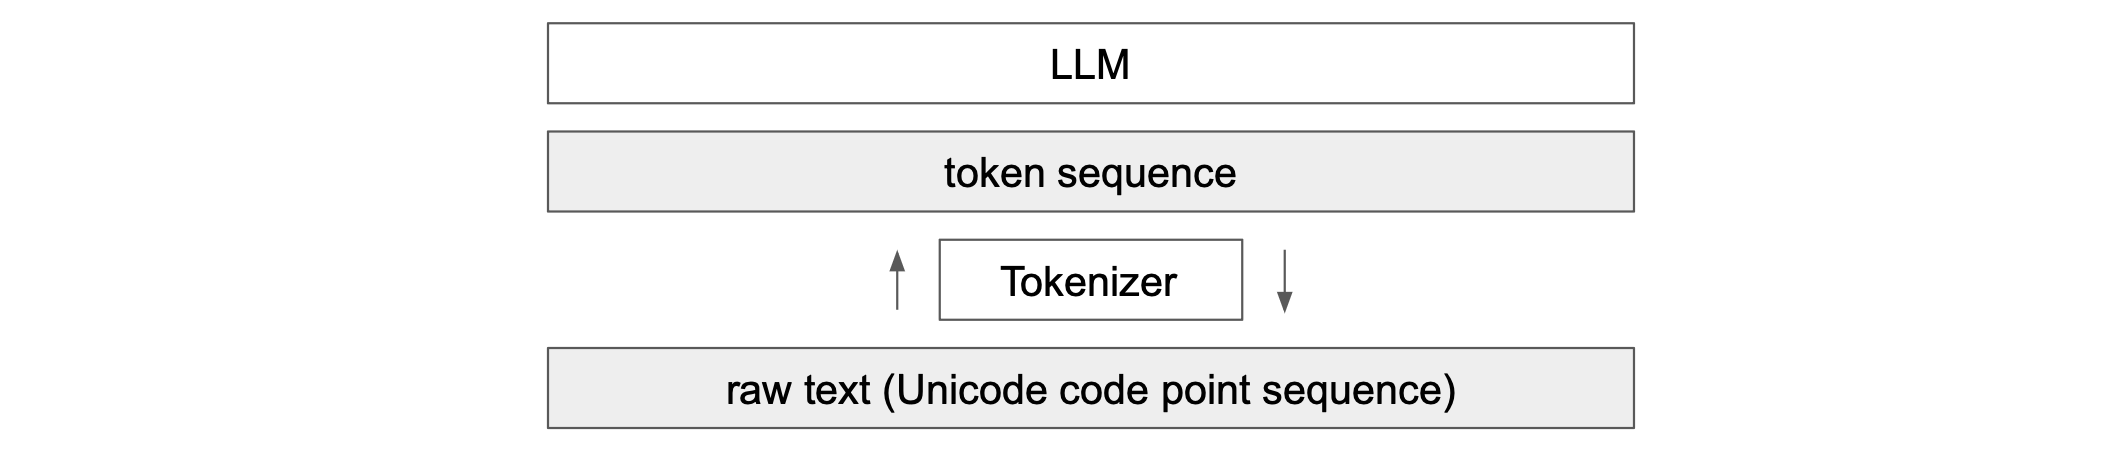

#### **Decoding**

Given a sequence of integers in the range [0, vocab_size], what is the text?


In [ ]:
vocab = {idx: bytes([idx]) for idx in range(256)}   # Initialize vocabulary with single-byte tokens (0–255)

In [ ]:

for (p0, p1), idx in merges.items():
    vocab[idx] = vocab[p0] + vocab[p1]              # Construct new token bytes by concatenating child tokens

def decode(ids):
    # given ids (list of integers), return Python string
    tokens = b"".join(vocab[idx] for idx in ids)    # Reconstruct the full byte sequence from token IDs
    text = tokens.decode("utf-8", errors="replace") # Decode bytes to UTF-8 text, replacing invalid sequences
    return text

print(decode([128]))                                # Decode a single raw-byte token


�


#### **Encoding**

The other way around: Given a string, what are the tokens?


In [ ]:
merges

{(101, 32): 256,
 (105, 110): 257,
 (115, 32): 258,
 (116, 104): 259,
 (101, 114): 260,
 (99, 111): 261,
 (116, 32): 262,
 (226, 128): 263,
 (44, 32): 264,
 (97, 110): 265,
 (111, 114): 266,
 (100, 32): 267,
 (97, 114): 268,
 (101, 110): 269,
 (257, 103): 270,
 (261, 100): 271,
 (121, 32): 272,
 (46, 32): 273,
 (97, 108): 274,
 (259, 256): 275}

In [ ]:
def encode(text):
  # given a string, return list of integers (the tokens)
  tokens = list(text.encode("utf-8"))
  while len(tokens) >= 2:
    stats = get_stats(tokens)
    pair = min(stats, key=lambda p: merges.get(p, float("inf")))
    if pair not in merges:
      break # nothing else can be merged
    idx = merges[pair]
    tokens = merge(tokens, pair, idx)
  return tokens

print(encode(""))

[]


In [ ]:
print(decode(encode("hello world")))

hello world


In [ ]:
text2 = decode(encode(text))
print(text2 == text)

True


In [ ]:
valtext = "Many common characters, including numerals, punctuation, and other symbols, are unified within the standard and are not treated as specific to any given writing system. Unicode encodes thousands of emoji, with the continued development thereof conducted by the Consortium as a part of the standard.[4] Moreover, the widespread adoption of Unicode was in large part responsible for the initial popularization of emoji outside of Japan. Unicode is ultimately capable of encoding more than 1.1 million characters."
valtext2 = decode(encode(valtext))
print(valtext2 == valtext)

True


### **6. Data Sampling With a Sliding Window**

- We train LLMs to generate one word at a time, so we want to prepare the training data accordingly where the next word in a sequence represents the target to predict:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/12.webp" width="700px">

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)  # Convert entire corpus to token IDs (the model trains on IDs, not raw strings)
print(len(enc_text))

5145


- For each text chunk, we want the inputs and targets
- Since we want the model to predict the next word, the targets are the inputs shifted by one position to the right

In [ ]:
enc_sample = enc_text[50:]

In [ ]:
context_size = 4 # Window length: number of tokens given as context to predict the next token

x = enc_sample[:context_size] # Input context tokens
y = enc_sample[1:context_size+1]  # Targets: same sequence shifted right by one token (next-token labels)

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


- One by one, the prediction would look like as follows:

In [ ]:
# # Show the next-token prediction task as the context grows from length 1 to context_size

for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i] # The immediate next token after that prefix

    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [ ]:
# Same as above, but decoded to human-readable text to verify the training pairs make sense
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


- Now, we implement a simple data loader that iterates over the input dataset and returns the inputs and targets shifted by one

- Install and import PyTorch

In [ ]:
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


- We use a sliding window approach, changing the position by +1:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/13.webp?123" width="700px">

- Create dataset and dataloader that extract chunks from the input text dataset
- Up to now, we manually created (x, y) pairs.
- We want a Dataset that automatically: tokenizes the corpus, creates overlapping context windows, returns (input_ids, target_ids) suitable for next-token prediction.”

- Dataset defines what one training example is, and DataLoader defines how batches are sampled.

In [ ]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text into token IDs (model never sees raw text)
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1" # "Number of tokenized inputs must at least be equal to max_length+1"


        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]              # Context window
            target_chunk = token_ids[i + 1: i + max_length + 1]    # Same window shifted by one token
            self.input_ids.append(torch.tensor(input_chunk))       # Convert to tensor for PyTorch
            self.target_ids.append(torch.tensor(target_chunk))


    def __len__(self):
        return len(self.input_ids) # Total number of training examples

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx] # One (input, target) pair

In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Use the GPT-2 tokenizer to match the vocabulary used by GPT-style models
    tokenizer = tiktoken.get_encoding("gpt2") # BPE

    # Wrap the text into a Dataset that produces (input_ids, target_ids)
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # DataLoader handles batching, shuffling, and parallel loading
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

- Let's test the dataloader with a batch size of 1 for an LLM with a context size of 4:

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [ ]:
# Initialize the DataLoader by calling the helper function defined earlier
dataloader = create_dataloader_v1(
    raw_text,      # The string of text
    batch_size=1,  # Number of samples to return at once (here, just one sequence)
    max_length=4,  # Each input sequence will consist of exactly 4 tokens
    stride=4,      # The 'jump' distance;
    shuffle=False  # Do not scramble the data; keep it in the original order of the text
)

# Convert the DataLoader object into a Python iterator so we can fetch batches manually
data_iter = iter(dataloader)

# Fetch the very first batch (contains one input tensor and one target tensor)
first_batch = next(data_iter)

# Display the result to the console to inspect the token IDs . These are the integer IDs for the first 4 tokens in your text (input,target)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


- An example using stride equal to the context length (here: 4) as shown below:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/14.webp" width="700px">

- We can also create batched outputs
- Note that we increase the stride here so that we don't have overlaps between the batches, since more overlap could lead to increased overfitting

In [ ]:
# Create a DataLoader into a single batch
dataloader = create_dataloader_v1(
    raw_text,
    batch_size=8,   # Now fetching 8 training examples at once
    max_length=4,
    stride=4,
    shuffle=False
)

# Initialize the iterator
data_iter = iter(dataloader)

# Unpack the next batch into two variables: inputs (X) and targets (Y)
inputs, targets = next(data_iter)

# Print the 8x4 matrix of input token IDs
print("Inputs:\n", inputs)

# Print the 8x4 matrix of target token IDs (each row shifted by 1)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


### **7. Creating Token Embeddings**

- The data is already almost ready for an LLM
- But lastly let us embed the tokens in a continuous vector representation using an embedding layer
- Usually, these embedding layers are part of the LLM itself and are updated (trained) during model training

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/15.webp" width="700px">

- Suppose we have the following four input examples with input ids 2, 3, 5, and 1 (after tokenization):

In [ ]:
input_ids = torch.tensor([2, 3, 5, 1])

In [ ]:
tokenizer.n_vocab

50257

- For the sake of simplicity, suppose we have a small vocabulary of only 6 words and we want to create embeddings of size 3:

In [ ]:
vocab_size = 6 # Define the size of our 'dictionary' (total unique tokens)
output_dim = 3 # Define the size of the vector for each token (how many numbers represent one word)

torch.manual_seed(123) # Set a random seed so the 'random' numbers generated are the same every time we run this
embedding_layer = torch.nn.Embedding(vocab_size, output_dim) # Initialize the embedding layer; essentially a lookup table of shape (6, 3)

- This would result in a 6x3 weight matrix:

In [ ]:
# Access the internal weight matrix of the embedding layer
# This is the 'master list' where all the vector values are stored
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


- For those who are familiar with one-hot encoding, the embedding layer approach above is essentially just a more efficient way of implementing one-hot encoding followed by matrix multiplication in a fully-connected layer, which is described [here](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch02/03_bonus_embedding-vs-matmul/embeddings-and-linear-layers.ipynb)
- Because the embedding layer is just a more efficient implementation that is equivalent to the one-hot encoding and matrix-multiplication approach it can be seen as a neural network layer that can be optimized via backpropagation

- To convert a token with id 3 into a 3-dimensional vector, we do the following:

In [ ]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


- Note that the above is the 4th row in the `embedding_layer` weight matrix
- To embed all four `input_ids` values above, we do

In [ ]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


- An embedding layer is essentially a look-up operation:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/16.webp?123" width="700px">

### **8. Encoding Word Positions**

- Embedding layer convert IDs into identical vector representations regardless of where they are located in the input sequence:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/17.webp" width="700px">

- Positional embeddings are combined with the token embedding vector to form the input embeddings for a large language model:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/18.webp" width="800px">

- The BytePair encoder has a vocabulary size of 50,257:
- Suppose we want to encode the input tokens into a 256-dimensional vector representation:

In [ ]:
vocab_size = 50257 # Define the full vocabulary size
output_dim = 256 # Define the size of the vector for each token (LLMs usually use 768+, but we use 256 here)

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim) # Create the embedding layer

- If we sample data from the dataloader, we embed the tokens in each batch into a 256-dimensional vector
- If we have a batch size of 8 with 4 tokens each, this results in a 8 x 4 x 256 tensor:

In [ ]:
# Create the DataLoader to fetch batches of 8 sequences, each 4 tokens long
max_length = 4
dataloader = create_dataloader_v1(
    raw_text,
    batch_size=8,
    max_length=max_length,
    stride=max_length,
    shuffle=False
)

# Convert to an iterator and fetch the first batch
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [ ]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

# uncomment & execute the following line to see how the embeddings look like
print(token_embeddings)

torch.Size([8, 4, 256])
tensor([[[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
         [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],

        [[ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421],
         [-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091],
         [ 1.9847, -0.6483, -0.1415,  ..., -0.3841, -0.9355,  1.4478],
         [ 0.9647,  1.2974, -1.6207,  ...,  1.1463,  1.5797,  0.3969]],

        [[-0.7713,  0.6572,  0.1663,  ..., -0.8044,  0.0542,  0.7426],
         [ 0.8046,  0.5047,  1.2922,  ...,  1.4648,  0.4097,  0.3205],
         [ 0.0795, -1.7636,  0.5750,  ...,  2.1823,  1.8231, -0.3635],
         [ 0.4267, -0.0647,  0.5686,  ..., -0.5209,  1.3065,  0.8473]],

        ...,

        [[-1.6156,  0.9610, -2.6437,  ..., -0.9645,  1.0888,  1.6383],
         [-0.3985, -0.9235, -1.31

- GPT-2 uses absolute position embeddings, so we just create another embedding layer:

In [ ]:
# The maximum number of tokens the model can process at once (4 in this case)
context_length = max_length

# Create an embedding layer for positions (0 to 3)
# It has 4 rows (one for each index) and 256 columns (to match token embeddings)
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

# Print the weight matrix: the actual vectors representing positions 0, 1, 2, and 3
print(pos_embedding_layer.weight)

Parameter containing:
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       requires_grad=True)


In [ ]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [ ]:
# torch.arange(max_length) creates a tensor of [0, 1, 2, 3]
# Passing this to the layer retrieves the specific vectors for those 4 positions
pos_embeddings = pos_embedding_layer(torch.arange(max_length))

# Display the dimensions of the positional vectors
# Expected: torch.Size([4, 256])
print(pos_embeddings.shape)

# Print the actual numerical values (the "GPS coordinates" for each slot)
print(pos_embeddings)

torch.Size([4, 256])
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       grad_fn=<EmbeddingBackward0>)


- To create the input embeddings used in an LLM, we simply add the token and the positional embeddings:

In [ ]:
# Check the shape of the token-only data (8 batches, 4 tokens, 256 features)
token_embeddings.shape

torch.Size([8, 4, 256])

In [ ]:
# Add the two tensors together: (8, 4, 256) + (4, 256)
# PyTorch 'broadcasts' the positional vectors across all 8 batch items automatically
input_embeddings = token_embeddings + pos_embeddings

# Display the final shape; it remains (8, 4, 256)
print(input_embeddings.shape)

# Print the final numerical representation that will actually enter the LLM
print(input_embeddings)

torch.Size([8, 4, 256])
tensor([[[ 2.2288,  0.5619,  0.8286,  ..., -0.6272, -0.2987,  0.8900],
         [ 2.0903, -0.4664, -0.0593,  ...,  0.9115, -1.0493, -1.6473],
         [-0.7158, -0.8304,  1.2494,  ...,  2.3952,  1.8773,  0.8051],
         [ 0.2703,  0.4029,  3.0514,  ...,  0.3595, -1.4548,  0.8310]],

        [[ 3.2835,  1.1749, -1.4150,  ..., -0.3281,  2.4332,  0.6924],
         [-0.2199, -0.9114, -0.1750,  ...,  1.5337, -0.1998,  0.1462],
         [ 1.5197, -1.4240,  0.4391,  ...,  1.0494, -1.4318,  2.3057],
         [ 0.2893,  0.8346, -0.1884,  ...,  1.9602,  0.8709,  0.8796]],

        [[ 0.9662,  0.0952, -0.4640,  ..., -1.0320,  1.6290,  1.7771],
         [ 2.4468, -0.2154,  1.4984,  ...,  1.8766,  0.5595, -0.1423],
         [-0.3856, -2.5393,  1.1556,  ...,  3.6157,  1.3267,  0.4944],
         [-0.2487, -0.5275,  2.0009,  ...,  0.2930,  0.5977,  1.3300]],

        ...,

        [[ 0.1219,  0.3991, -3.2740,  ..., -1.1921,  2.6637,  2.6728],
         [ 1.2438, -1.6436, -1.11

- In the initial phase of the input processing workflow, the input text is segmented into separate tokens
- Following this segmentation, these tokens are transformed into token IDs based on a predefined vocabulary:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/19.webp" width="600px">

# **B) Running Pre-trained LLMs and Comparing LLM Tokenizers**



## **[OPTIONAL]** - Installing Packages

If you are viewing this notebook on Google Colab (or any other cloud vendor), you need to **uncomment and run** the following codeblock to install the dependencies for this section:

---

💡 **NOTE**: We will want to use a GPU to run the examples in this notebook. In Google Colab, go to
**Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**.

---

In [ ]:
%%capture
!pip install --upgrade transformers==4.41.2 sentence-transformers==3.0.1 gensim==4.3.2 scikit-learn==1.5.0 accelerate==0.31.0 peft==0.11.1 scipy==1.10.1 numpy==1.26.4

## **0) Comparing Trained LLM Tokenizers**


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# A list of RGB color codes (Soft pastels) used for the background of the tokens
colors_list = [
    '102;194;165', '252;141;98', '141;160;203',
    '231;138;195', '166;216;84', '255;217;47'
]

def show_tokens(sentence, tokenizer_name):
    # Load the specific tokenizer (e.g., GPT-2, Llama, or Phi-3)
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    # Convert the string sentence into a list of integer Token IDs
    token_ids = tokenizer(sentence).input_ids

    # Loop through each token ID to decode and print it
    for idx, t in enumerate(token_ids):
        # Use ANSI escape codes to set the background color and print the decoded word
        # \x1b[0;30;48;2;...m creates the colored background in the terminal
        print(
            f'\x1b[0;30;48;2;{colors_list[idx % len(colors_list)]}m' +
            tokenizer.decode(t) +
            '\x1b[0m',
            end=' ' # Space out the tokens so they don't overlap
        )

In [ ]:
text = """
English and CAPITALIZATION
🎵 鸟
show_tokens False None elif == >= else: two tabs:"    " Three tabs: "       "
12.0*50=600
"""

In [ ]:
show_tokens(text, "bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

[CLS] english and capital ##ization [UNK] [UNK] show _ token ##s false none eli ##f = = > = else : two tab ##s : " " three tab ##s : " " 12 . 0 * 50 = 600 [SEP] 

- BERT uses WordPiece tokenization. It recognizes "capital" as a root word and ##ization as a common suffix. The ## indicates that this token is a continuation of the previous word, not a new word.
- The musical note (🎵) and the Chinese character (鸟) are both rendered as [UNK]. This specific BERT model was trained primarily on English text.
- [CLS]: Added to the very beginning. This is a "Classification" token used by BERT to represent the meaning of the entire sequence.
- Python Keywords: Keywords like false, none, and elif are recognized as single tokens because they appear frequently in the training data.
- Operators: Notice how == and >= are split into individual tokens like = = and > =. BERT often treats punctuation and math symbols as individual units.

In [ ]:
show_tokens(text, "bert-base-cased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

[CLS] English and CA ##PI ##TA ##L ##I ##Z ##AT ##ION [UNK] [UNK] show _ token ##s F ##als ##e None el ##if = = > = else : two ta ##bs : " " Three ta ##bs : " " 12 . 0 * 50 = 600 [SEP] 

- Case Preservation: Unlike the "uncased" version, this model keeps "English" capitalized.

- Aggressive Splitting: Because it has to store both "A" and "a", its vocabulary fills up faster. This forces it to break words into much smaller fragments (e.g., CA ##PI ##TA ##L ##I ##Z ##AT ##ION).

- Symbol Limits: Like its uncased brother, it still returns [UNK] for emojis and non-English characters.

- Structural Consistency: Still maintains the [CLS] and [SEP] tokens for classification tasks.

In [ ]:
show_tokens(text, "gpt2")


 English  and  CAP ITAL IZ ATION 
 � � �  � � � 
 show _ t ok ens  False  None  el if  ==  >=  else :  two  tabs :"        "  Three  tabs :  "              " 
 12 . 0 * 50 = 600 
 

- Case Sensitivity: Unlike "bert-base-uncased," GPT-2 is cased. It preserves the original capitalization, keeping "English" and "CAPITALIZATION" exactly as they were written.

- Byte-Pair Encoding (BPE) Splitting: GPT-2 uses BPE to break words into sub-units. For example, "CAPITALIZATION" is split into CAP, ITAL, IZ, and ATION.

- Visualizing Spaces (The "Ġ" Symbol): If you look closely at the colored blocks, some words have a small gap or leading space. GPT-2 treats spaces as part of the following token (often represented internally by a Ġ character).

- Handling Emojis and Symbols: Unlike BERT, which showed [UNK], GPT-2 can represent complex symbols like the musical note (🎵) and the Chinese character (鸟). However, it doesn't always have a single token for them; it often breaks them down into multiple "byte-level" tokens (the colorful sequence of small blocks).

- Whitespace Preservation: GPT-2 is much better at "seeing" structure. It captures the tabs and multiple spaces as individual tokens, whereas BERT largely ignored them.

- Number and Math Logic: Numbers are broken down into smaller chunks (e.g., 12 . 0). This allows the model to build larger numbers from a small set of digit-based tokens.


In [ ]:
show_tokens(text, "google/flan-t5-small")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

English and CA PI TAL IZ ATION  <unk>  <unk> show _ to ken s Fal s e None  e l if = = > = else : two tab s : " " Three tab s : " " 12. 0 * 50 = 600 </s> 

- Case Sensitivity: Like GPT-2 and BERT-cased, Flan-T5 is cased and preserves the capitalization of "English" and "CAPITALIZATION".

- Whitespace as a Character: It treats spaces as actual characters (indicated by the small colored blocks before words), ensuring that the structural layout of the text is preserved.

- Sub-word Splitting: It aggressively breaks down large or complex words into smaller components (e.g., "CAPITALIZATION" becomes CA PI TAL IZ ATION).

- Unknown Character Handling: Similar to BERT, it cannot recognize the emoji or Chinese character, replacing them with the <unk> (unknown) token.

- Special End Token: It appends a </s> (end-of-string) token to indicate the completion of the text sequence.

- Code and Math: It breaks down logical operators (like ==) and numerical expressions (like 12.0) into individual constituent characters or small sub-units.

In [ ]:
show_tokens(text, "microsoft/Phi-3-mini-4k-instruct")

 
 English and C AP IT AL IZ ATION 
 � � � �  � � � 
 show _ to kens False None elif == >= else : two tabs :"    " Three tabs : "       " 
 1 2 . 0 * 5 0 = 6 0 0 
 

- Case Preservation: Like GPT-2, it preserves capitalization (e.g., "English" and "CAPITALIZATION").

- Sub-word Efficiency: It breaks complex words into logical chunks, such as C AP IT AL IZ ATION.

- Byte-Level Fallback: For the emoji and Chinese characters, it doesn't show an unknown token like [UNK]. Instead, it breaks them into a series of byte-level tokens (the colorful sequence of diamond symbols), allowing the model to "see" every character even if it's not in the common vocabulary.

- Whitespace Sensitive: It captures tabs and multiple spaces as distinct tokens, which is critical for understanding code structure.

- Clean Generation: It does not require structural prefixes like [CLS], making it streamlined for chat and instruction-following tasks.

In [ ]:
# The official is `tiktoken` but this the same tokenizer on the HF platform
show_tokens(text, "Xenova/gpt-4")

tokenizer_config.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.01M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/917k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.23M [00:00<?, ?B/s]


 English  and  CAPITAL IZATION 
 � � �  � � � 
 show _ tokens  False  None  elif  ==  >=  else :  two  tabs :"      "  Three  tabs :  "         " 
 12 . 0 * 50 = 600 
 

In [ ]:
# You need to request access before being able to use this tokenizer
show_tokens(text, "bigcode/starcoder2-15b")

config.json:   0%|          | 0.00/803 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 49151), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 49151), got 50256. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/7.88k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/777k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/442k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.06M [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



 English  and  CAPITAL IZATION 
 � � �   � � 
 show _ tokens  False  None  elif  ==  >=  else :  two  tabs :"      "  Three  tabs :  "         " 
 1 2 . 0 * 5 0 = 6 0 0 
 

- Code-Centric Efficiency: As a model built for programming, StarCoder2 is exceptionally efficient with technical syntax. Notice how it handles CAPITAL and IZATION as two large, logical blocks compared to more fragmented general-purpose models.

- Whitespace Preservation: It treats tabs and multiple spaces as unique, distinct tokens. This is critical because, in many programming languages (like Python), indentation carries functional meaning.

- Symbol Handling: It tends to group logical operators like == and >= more cleanly, viewing them through the lens of programming logic rather than just individual punctuation marks.

- Byte-Level Fallback: Like the other modern decoder models (GPT-2, Phi-3, Galactica), it handles emojis (🎵) and non-Latin characters (鸟) by breaking them into byte-level fragments (the diamond symbols) instead of using an "unknown" tag. This ensures no data is lost during encoding.

- Case Sensitivity: It preserves capitalization perfectly, which is essential for distinguish between variables like myVariable and MyVariable in code.

In [ ]:
show_tokens(text, "facebook/galactica-1.3b")

config.json:   0%|          | 0.00/789 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.14M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.00 [00:00<?, ?B/s]


 English  and  CAP ITAL IZATION 
 � � � �  � � � 
 show _ tokens  False  None  elif   ==   > =  else :  two  t abs : "      "  Three  t abs :   "         " 
 1 2 . 0 * 5 0 = 6 0 0 
 

- Case Sensitivity: Like GPT-2 and Phi-3, Galactica is cased. It keeps "English" and "CAPITALIZATION" in their original forms.

- Scientific Specialization: Because it was trained on technical papers, it is highly efficient at tokenizing mathematical expressions and code. Notice how it handles 1 2 . 0 * 5 0 = 6 0 0 as a sequence of distinct, meaningful units.

- Sub-word Splitting: It splits "CAPITALIZATION" into CAP, ITAL, and IZATION. This is a slightly more "holistic" split than BERT, as it keeps recognizable word roots together.

- Byte-Level Representation: Like Phi-3 and GPT-2, it handles unknown characters (the emoji and Chinese character) by breaking them into byte-level fragments (the diamond symbols) rather than using a generic [UNK] tag.

- Strict Whitespace Handling: Galactica is extremely precise with whitespace, treating tabs and even single spaces between words as distinct tokens. This is vital for correctly interpreting mathematical formulas and LaTeX code.

- Clean Inputs: Similar to other decoder-only models, it doesn't require "boundary" tokens like [CLS], though it may use internal markers for specific scientific data types.

## **1) Downloading and Running An LLM**

The first step is to load our model onto the GPU for faster inference. Note that we load the model and tokenizer separately and keep them as such so that we can explore them separately.

In [ ]:
from google.colab import userdata
HF_TOKEN = userdata.get('hf')

#### AutoTokenizer: The Bridge to Numbers
#### The Core Problem

A neural network is, at its heart, a giant math function. It takes numbers in, does matrix multiplications, and spits numbers out. It has **no concept of letters, words, or sentences**.

So before any text reaches the model, it must be converted into a sequence of integers. That is the tokenizer's job.




#### What Exactly Is a Token?

A token is the smallest unit the model works with. It is usually a sub-word — not quite a character, not quite a full word.

```
"unbelievable"  →  ["un", "believ", "able"]      ← 3 tokens
"cat"           →  ["cat"]                         ← 1 token
"ChatGPT"       →  ["Chat", "G", "PT"]            ← 3 tokens
```

Each token maps to a unique integer ID in the model's vocabulary:

```
"un"      →  4895
"believ"  →  7283
"able"    →  1075
```

This mapping table is fixed — it is learned during tokenizer training and never changes.


#### Why `Auto` in AutoTokenizer?

Different models use different tokenization schemes:

| Model Family | Tokenizer Type |
|---|---|
| BERT, RoBERTa | WordPiece |
| GPT-2, GPT-4 | Byte-Pair Encoding (BPE) |
| LLaMA, Mistral | SentencePiece (BPE variant) |
| Phi-3 | tiktoken-style BPE |

`AutoTokenizer.from_pretrained("model-name")` automatically detects which tokenizer the model needs and loads it — you do not need to know or specify the type manually.

```python
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/phi-3-mini-4k-instruct")
```



#### Key Responsibilities

#### 1. Standardization — Exact Reproducibility

The tokenizer used at **inference time must be identical** to the one used at **training time**.

Why? The model learned associations between token IDs and meanings. If you swap tokenizers, the same string produces different IDs — the model sees completely different inputs and produces garbage.

```python
# These two tokenizers produce DIFFERENT IDs for the same text
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")

text = "Hello world"
print(tokenizer_bert(text)["input_ids"])   # [101, 7592, 2088, 102]
print(tokenizer_gpt2(text)["input_ids"])   # [15496, 995]
```

`AutoTokenizer` guarantees you get the right one automatically.



#### 2. Special Tokens — Structural Markers

Models are not just fed raw text. They need structural signals embedded in the token sequence to understand context.

**BERT-style models** wrap every input:
```
[CLS] The cat sat on the mat [SEP]
  ↑                            ↑
"Start of sequence"        "End of sequence"
```

**GPT-style models** use an end-of-text marker:
```
The cat sat on the mat <|endoftext|>
```

**Chat/instruction models** (like Phi-3) use full conversation templates:
```
<|user|>
What is BPE?
<|end|>
<|assistant|>
```

`AutoTokenizer` inserts all of these automatically — you just pass raw text.

```python
inputs = tokenizer("What is BPE?", return_tensors="pt")
# Special tokens are added silently
```

Without these markers, the model cannot tell where a prompt ends, where an answer begins, or whether it is doing classification vs. generation.


#### 3. Padding and Truncation — Fitting the Context Window

Neural networks process fixed-size batches. Every sequence in a batch must be the same length.

**Padding** — Short sequences get padded with a special `[PAD]` token:
```
Sequence 1: [101, 7592, 2088, 102, 0, 0, 0]   ← padded
Sequence 2: [101, 7592, 1996, 3899, 2003, 9005, 102]
```

**Truncation** — Long sequences get cut to fit the model's maximum length (e.g., 4096 tokens for Phi-3):
```python
inputs = tokenizer(
    very_long_text,
    padding=True,
    truncation=True,
    max_length=4096,
    return_tensors="pt"
)
```

The tokenizer also produces an **attention mask** — a binary array that tells the model which positions are real tokens (1) and which are padding (0), so padding doesn't influence the computation.

```
input_ids:      [101, 7592, 2088, 102,  0,   0 ]
attention_mask: [  1,    1,    1,   1,  0,   0 ]
```

---

#### What the Tokenizer Returns

```python
output = tokenizer("Hello world", return_tensors="pt")

# output contains:
# {
#   "input_ids":      tensor([[101, 7592, 2088, 102]]),   ← integer IDs
#   "attention_mask": tensor([[  1,    1,    1,   1]])     ← 1=real, 0=pad
# }
```

These tensors go directly into the model.

---
*One-Line Summary*

> The tokenizer converts raw text → integer IDs (with all structural markers added), so the model always receives input in exactly the same format it was trained on.

### AutoModelForCausalLM — The Inference Engine


#### Unpacking the Name

```
Auto  Model  For  Causal  LM
 │      │     │     │      │
 │      │     │     │      └── Language Model (predicts tokens)
 │      │     │     └───────── Causal (left-to-right, no peeking ahead)
 │      │     └─────────────── Task-specific head attached on top
 │      └───────────────────── The transformer neural network
 └──────────────────────────── Auto-detects architecture from model name
```

---

## The Big Picture: What Does This Class Actually Do?

When you write:

```python
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("microsoft/phi-3-mini-4k-instruct")
```

You are loading:

1. The **architecture** — transformer layers, attention heads, feed-forward networks
2. The **weights** — billions of learned floating-point numbers (parameters)
3. The **LM head** — the final layer that produces token probabilities
All three live inside this single object.

#### Core Concept 1: Next-Token Prediction

This is the fundamental task the model was trained on.

Given a sequence of tokens, predict what comes next.

```
Input:   "The cat sat on the"
Predict: "mat"  (probability 0.73)
         "floor" (probability 0.11)
         "roof"  (probability 0.04)
         ...
```

The model assigns a probability to **every token in the vocabulary** at every step.

Training on this simple task across trillions of tokens is how the model learns grammar, facts, reasoning, and language patterns — all implicitly baked into the weights.

---

#### Core Concept 2: Why "Causal"?

"Causal" means the model can only look **left** — it sees past tokens, never future ones.

```
Tokens:  [The]  [cat]  [sat]  [on]  [the]  [mat]
           ↑      ↑      ↑     ↑      ↑      ↑
           │      │      │     │      │      │
When predicting "mat", the model sees:
           ✓      ✓      ✓     ✓      ✓      ✗ (blocked)
```

This is enforced with a **causal attention mask** — a triangular mask that zeroes out any attention to future positions.

The alternative (used in BERT) is **bidirectional** — the model sees the whole sentence at once, which is great for understanding but cannot generate text autoregressively.

| | BERT (Bidirectional) | GPT / Phi / LLaMA (Causal) |
|---|---|---|
| Sees future tokens? | Yes | No |
| Good for | Classification, NLU | Text generation, chat |
| Generates text? | Not natively | Yes |

---

#### Core Concept 3: The Language Modeling Head

The base transformer produces a **hidden state vector** for each token position — a dense numerical representation of meaning at that position, typically 2048 to 8192 numbers wide.

```
Input token IDs  →  [Transformer Layers]  →  Hidden states
                                                    ↓
                                             [LM Head (linear layer)]
                                                    ↓
                                          Logits over vocabulary
                                          (one number per token in vocab)
                                                    ↓
                                             [Softmax]
                                                    ↓
                                          Probability distribution
```

The **LM head** is a single linear layer that projects the hidden state to the vocabulary size:

```
hidden_state shape: [batch, seq_len, hidden_dim]   e.g. [1, 10, 3072]
       ↓  linear layer (no activation)
logits shape:       [batch, seq_len, vocab_size]   e.g. [1, 10, 32064]
```

Every position produces 32,064 numbers (for Phi-3) — one per vocabulary token. Softmax turns these into probabilities. The next token is sampled or greedy-picked from this distribution.

---

#### Core Concept 4: Weight Management

A model like Phi-3-mini has **3.8 billion parameters**. Each is a 32-bit float (4 bytes) by default.

```
3.8B × 4 bytes = ~15 GB  (fp32)
3.8B × 2 bytes = ~7.5 GB (fp16 / bf16)
3.8B × 1 byte  = ~3.8 GB (int8 quantized)
```

`from_pretrained` handles loading this into memory, with options to control precision:

```python
import torch

model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-3-mini-4k-instruct",
    torch_dtype=torch.float16,   # use half precision → saves memory
    device_map="auto"            # auto-split across CPU/GPU if needed
)
```

Without `device_map="auto"`, the whole model loads into CPU RAM and inference is extremely slow.

---

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load the actual neural network (the model)
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct", # The specific model ID from Hugging Face
    device_map="cuda",                  # Automatically move the model to your GPU
    torch_dtype="auto",                 # Use the best precision (e.g., float16) for your hardware
    trust_remote_code=False,            # Security flag: don't run custom code from the repo
)

# Load the tokenizer (the 'translator') that matches this specific model
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [ ]:
# Define the instruction for the model using its specific chat format
prompt = "Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened.<|assistant|>"

# Convert the text into a tensor of Token IDs and move them to the GPU (cuda)
# 'return_tensors="pt"' ensures the output is a PyTorch tensor
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")

# Use the model's 'generate' function to predict the next tokens
generation_output = model.generate(
  input_ids=input_ids,      # The 'context' the model looks at
  max_new_tokens=150         # Limit the response to 20 new words/tokens
)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [ ]:
print(input_ids)

tensor([[14350,   385,  4876, 27746,  5281,   304, 19235,   363,   278, 25305,
           293, 16423,   292,   286,   728,   481, 29889, 12027,  7420,   920,
           372,  9559, 29889, 32001]], device='cuda:0')


In [ ]:
for id in input_ids[0]:
   print(tokenizer.decode(id))

Write
an
email
apolog
izing
to
Sarah
for
the
trag
ic
garden
ing
m
ish
ap
.
Exp
lain
how
it
happened
.
<|assistant|>


In [ ]:
generation_output

tensor([[14350,   385,  4876, 27746,  5281,   304, 19235,   363,   278, 25305,
           293, 16423,   292,   286,   728,   481, 29889, 12027,  7420,   920,
           372,  9559, 29889, 32001,  3323,   622, 29901, 17778, 29888,  2152,
          6225, 11763,   363,   278, 19906,   292,   341,   728,   481,    13,
            13,    13, 29928,   799, 19235, 29892,    13,    13,    13, 29902,
          4966,   445,  2643, 14061,   366,  1532, 29889,   306,   626,  5007,
           304,  4653,   590,  6483,   342,  3095, 11763,   363,   278,   443,
          6477,   403, 15134,   393, 10761,   297,   596, 16423, 22600, 29889,
            13,    13,    13,  2887,   366,  1073, 29892,   306,   505,  2337,
          7336,  2859,   278,   724,  1600, 15409,   310,   596, 16423,   322,
           278,  8856,   362,   366,  1925,   964,  7344,   292,   372, 29889,
           739,   471,   411,  2107, 28883,   393,   306, 11423,   635,  5625,
          4063,   777,   310,   596,  3691, 24688, 1

In [ ]:
print(tokenizer.decode(generation_output[0]))

Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened.<|assistant|> Subject: Heartfelt Apologies for the Gardening Mishap


Dear Sarah,


I hope this message finds you well. I am writing to express my deepest apologies for the unfortunate incident that occurred in your garden yesterday.


As you know, I have always admired the serene beauty of your garden and the dedication you put into maintaining it. It was with great regret that I accidentally damaged some of your prized rose bushes while attempting to install a new irrigation system.


The mishap happened when I miscalculated the placement of the pipes, which led to a small section of the rose bushes being up


In [ ]:
import torch

print(tokenizer.decode(torch.tensor(3323)))
print(tokenizer.decode(torch.tensor(622)))
print(tokenizer.decode(torch.tensor([3323, 622])))
print(tokenizer.decode(torch.tensor(29901)))

Sub
ject
Subject
:


---
## **2) Understanding Generation: Parameters That Control What the LLM Says**

Running an LLM is not just `model.generate(input_ids)`. The model outputs a **probability distribution** over its entire vocabulary at every step. How you *sample* from that distribution determines whether the output is creative, focused, repetitive, or random.

This section covers:
1. **GPT-2 locally** – small enough to run on CPU, great for experiments
2. **Greedy decoding** – always pick the highest-probability token
3. **Temperature** – scale the probabilities before sampling
4. **Top-k sampling** – only sample from the k most likely tokens
5. **Top-p (nucleus) sampling** – only sample from the smallest set of tokens whose cumulative probability ≥ p
6. **Beam search** – explore multiple candidate sequences simultaneously


### 📐 The Big Picture: From Logits → Token

<img src="https://huggingface.co/blog/assets/02_how-to-generate/greedy_search.png" width="700">

*At each step, the model produces a vector of raw scores (logits) — one per vocabulary token. Generation strategies decide how to pick the next token from those scores.*


### Step 0 — Install / Import


In [ ]:

# transformers is already installed; make sure it is recent enough
!pip install -q transformers torch


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# ── Load GPT-2 (117M parameters — runs fine on CPU) ──────────────────────
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_model     = AutoModelForCausalLM.from_pretrained("gpt2")
gpt2_model.eval()   # Disable dropout — we are doing inference, not training

print("GPT-2 loaded ✓")
print(f"Parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 loaded ✓
Parameters: 124,439,808


### Peek inside the model


In [ ]:
# The embedding table: 50 257 tokens × 768 dimensions
print(gpt2_model.transformer.wte)
print()

# 12 Transformer decoder blocks
print(f"Number of Transformer layers: {len(gpt2_model.transformer.h)}")

# The language-modelling head maps hidden states → logits over vocabulary
print(f"LM head shape: {gpt2_model.lm_head.weight.shape}")


Embedding(50257, 768)

Number of Transformer layers: 12
LM head shape: torch.Size([50257, 768])


### Helper: `generate_text` wrapper


In [ ]:
def generate_text(prompt, model, tokenizer,
                  max_new_tokens=100,
                  # --- decoding strategy ---
                  do_sample=True,
                  temperature=1.0,
                  top_k=50,
                  top_p=0.95,
                  num_beams=1,
                  repetition_penalty=1.0,
                  # --- output ---
                  skip_special_tokens=True):
    """
    Encode *prompt*, run generation with the chosen strategy, decode the output.
    Returns the generated text (not including the prompt).
    """
    input_ids = tokenizer.encode(prompt, return_tensors="pt")

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            num_beams=num_beams,
            repetition_penalty=repetition_penalty,
            pad_token_id=tokenizer.eos_token_id,  # suppress a warning in GPT-2
        )

    # Decode only the *newly generated* tokens (slice off the prompt)
    new_tokens = output_ids[0, input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=skip_special_tokens)


### 1. Greedy Decoding — always pick the most likely next token

At each step, the model looks at the probability distribution over the entire vocabulary and simply picks the token with the highest score — no randomness, no lookahead. Think of it as always taking the most obvious next word, one step at a time.

**Pro:** deterministic, fast.  
**Con:** tends to produce repetitive, boring text. Once the model commits to a bad word, it doubles down.

In [ ]:
prompt = "The key idea behind transformers is"

# do_sample=False → greedy (no randomness)
greedy_out = generate_text(
    prompt, gpt2_model, gpt2_tokenizer,
    do_sample=False, max_new_tokens=80
)
print("GREEDY OUTPUT:")
print(prompt + greedy_out)


[transformers] The following generation flags are not valid and may be ignored: ['top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


GREEDY OUTPUT:
The key idea behind transformers is to make them more efficient and more efficient.

The first step is to make them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient by making them more efficient


### 2. Temperature — control the sharpness of the probability distribution

### What Even Is Temperature?

Temperature is borrowed from physics — in thermodynamics, high temperature means particles move more chaotically and unpredictably; low temperature means they settle into order. Same intuition here: **high T = chaotic/creative outputs, low T = settled/predictable outputs.**

Think of it like a **confidence dial** on the model. At every step, the model has a ranked list of candidate next tokens with associated probabilities. Temperature doesn't change the ranking — it changes **how steep the gap is** between rank 1 and rank 2, 3, 4...


```
Logits (raw):   cat=5.2   dog=4.8   fish=1.1   table=0.3

T=0.5 (sharp):  cat=91%   dog=8%    fish=~0%   table=~0%   ← model is very sure
T=1.0 (normal): cat=55%   dog=40%   fish=4%    table=1%    ← default
T=2.0 (flat):   cat=35%   dog=32%   fish=20%   table=13%   ← anything could happen
```

At low T, the model almost always picks `cat`. At high T, `table` starts getting real chances — which is sometimes creative, sometimes incoherent.



### The Math

The model's raw output is a list of logits — one score per vocabulary token. Temperature is a single number you divide those scores by before converting them to probabilities. A low T amplifies the gap between confident and unlikely tokens; a high T shrinks it, making the model less sure of itself.

Before sampling, each logit $z_i$ is divided by **T**:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

This is just softmax — but with the scores scaled before exponentiation.

---

## Effect of Different Values

| Temperature | Effect |
|-------------|--------|
| T → 0 | Approaches greedy: almost all probability on the top token |
| T = 1 | Unmodified distribution (default) |
| T > 1 | Flatter distribution → more surprising / random outputs |


In [ ]:
prompt = "Once upon a time in a kingdom far away,"

for temp in [0.2, 0.7, 1.0, 1.5]:
    out = generate_text(
        prompt, gpt2_model, gpt2_tokenizer,
        do_sample=True, temperature=temp,
        top_k=0, top_p=1.0,   # disable top-k / top-p to isolate temperature
        max_new_tokens=40
    )
    print(f"\n── Temperature {temp} ──")
    print(prompt + out)



── Temperature 0.2 ──
Once upon a time in a kingdom far away, a man was born, and he was called the son of a man. He was called the son of a man, and he was called the son of a man. He was called the son of

── Temperature 0.7 ──
Once upon a time in a kingdom far away, the King would approach the king's arms and proclaim to him, "I will not allow you to enter the kingdom of my king, nor the kingdom of any of my people." Then he would say

── Temperature 1.0 ──
Once upon a time in a kingdom far away, there appeared a restful two-thirds of human Nature, who were not their own kind, displaying the filial features and coarse look of cruelty and luxury, the quaint apparel of a man and his

── Temperature 1.5 ──
Once upon a time in a kingdom far away, Portugal lay cheered towards his knights. Scimona commander Thomas Galhard Courtney Mofran Reyes ac Pensilion Elbro artillery yearflags choc believe Obridgeaize de Vendavga Senegal crushing


### When to Use What

| Use Case | Recommended T |
|---|---|
| Factual Q&A, code generation | 0.1 – 0.4 |
| Chat / general assistant | 0.7 – 1.0 |
| Creative writing, brainstorming | 1.0 – 1.5 |
| Exploration / diversity sampling | > 1.5 (use carefully) |

### 3.Top-k Sampling — restrict the candidate pool to the k highest-probability tokens

Greedy decoding picks just 1 token; pure sampling picks from all 50,000+. Top-k is the middle ground — at each step, throw away every token except the k most likely ones, then sample freely within that shortlist. This prevents the model from ever randomly landing on a bizarre low-probability token, while still keeping enough variety to avoid repetition.

After sorting all tokens by probability, only the top **k** are kept. Their probabilities are re-normalised before sampling.

```
Full vocab (50 257 tokens) → keep top k → renormalise → sample
```

**Good default:** `top_k=50`. Very large k ≈ no filtering; k=1 ≈ greedy.


In [ ]:
prompt = "The future of artificial intelligence will"

for k in [1, 10, 50, 200]:
    out = generate_text(
        prompt, gpt2_model, gpt2_tokenizer,
        do_sample=True, temperature=1.0,
        top_k=k, top_p=1.0,
        max_new_tokens=40
    )
    label = "greedy" if k == 1 else f"top_k={k}"
    print(f"\n── {label} ──")
    print(prompt + out)



── greedy ──
The future of artificial intelligence will be determined by the future of the human race.

The future of artificial intelligence will be determined by the future of the human race.

The future of artificial intelligence will be determined by the

── top_k=10 ──
The future of artificial intelligence will depend, at least in part, on what the new technology does and how it works, but this is what the new technology is all about—how it can make things that we didn't even know

── top_k=50 ──
The future of artificial intelligence will be based on the ability of the machine to master the world beyond what we know and perceive, and also on the ability of humans to make conscious decisions based on what they see, hear, or smell

── top_k=200 ──
The future of artificial intelligence will depend on every one of us. I hope that nothing will stand in the way of it. The question is still on whether or not we want it. And there is so much we cannot decide.


### 4. Top-p (Nucleus) Sampling — adaptive pool size

#### The Problem with Top-k

Top-k always keeps exactly k tokens — even when the model is extremely confident about the next word. If the model is 99% sure the next token is `"the"`, you are still sampling from 50 candidates, introducing unnecessary noise. Top-p fixes this by making the pool size **a function of the model's own confidence**.

---

## How It Works

Sort tokens by probability (highest first). Keep adding tokens to the *nucleus* until their cumulative probability ≥ **p**. Sample only from the nucleus.

```
Sorted tokens:   "cat"=0.60  "dog"=0.25  "fish"=0.10  "table"=0.03  "sky"=0.02 ...

With top_p=0.95:
  0.60              → cumsum = 0.60  (keep)
  0.60 + 0.25       → cumsum = 0.85  (keep)
  0.85 + 0.10       → cumsum = 0.95  ✓ threshold reached → stop

Nucleus = ["cat", "dog", "fish"]  — only 3 tokens out of 50,257
```

Re-normalise these 3 probabilities and sample from them. Everything below the threshold is simply discarded.



#### Adaptive Pool Size

The pool size adapts dynamically based on how spread out the distribution is:

- When the model is **very confident** → nucleus is tiny (e.g., 3 tokens reach p=0.95)
- When the model is **uncertain** → nucleus is large (e.g., 500 tokens needed to reach p=0.95)
This is what top-k cannot do. A fixed k=50 is too loose when the model is confident, and potentially too tight when it is genuinely unsure between many plausible continuations. Top-p automatically scales with the situation.


In [ ]:
prompt = "The ocean is"

for p in [0.5, 0.80, 0.95, 1.0]:
    out = generate_text(
        prompt, gpt2_model, gpt2_tokenizer,
        do_sample=True, temperature=1.0,
        top_k=0,        # disable top-k
        top_p=p,
        max_new_tokens=40
    )
    print(f"\n── top_p={p} ──")
    print(prompt + out)



── top_p=0.5 ──
The ocean is full of small fish, and a little bit of salt can help to keep them warm.

The fish are also called "fish bait," and are a type of bait used to lure fish to

── top_p=0.8 ──
The ocean is made of little fuel-burning chemicals called propane and is not moving at the speed of light. This difference is so subtle that we rarely see it in the water.

The study says the

── top_p=0.95 ──
The ocean is mostly composed of the cold, brittle warm elements of the undersea crust. During the summer some of these weak and overburden crust deposits appear on the left surface while other albedo deposits run

── top_p=1.0 ──
The ocean is the outsiders, and the whales are taking us back among them." Nathalie McCann/SweetJack magazine via Getty Images 1/13 Charles Picflocke m Sanctu Ops 1911, No two


### 5.Combining top_k + top_p (the recommended default)

In practice, top_k and top_p are often used **together** as a two-stage filter:
1. Keep only the top-k tokens.
2. Within those k tokens, further restrict to the nucleus (top-p).


In [ ]:
prompt = "Scientists have recently discovered that"

# The combination OpenAI often recommends: top_k=50, top_p=0.95, temp=0.7
out = generate_text(
    prompt, gpt2_model, gpt2_tokenizer,
    do_sample=True,
    temperature=0.7,
    top_k=50,
    top_p=0.95,
    max_new_tokens=100
)
print("Combined (top_k=50, top_p=0.95, temp=0.7):")
print(prompt + out)


### 6. Beam Search — explore multiple hypotheses

#### The Problem with Greedy (Motivation)

Greedy decoding commits to one token at each step. This creates a trap: a locally good choice can lead to a globally bad sentence.

```
Prompt: "The weather today is"

Greedy picks:   "nice"  → "nice and"  → "nice and sunny"   ← fine
                                                              but what if...
                "nice"  → "nice but"  → dead end, awkward continuation
```

Once greedy picks `"nice"`, it is stuck. It never backtracks. Beam search keeps multiple paths alive so a slightly worse first token can still lead to the best overall sentence.



### How It Works

Instead of committing to one token at each step, beam search keeps the **B best partial sequences** (beams) alive simultaneously.

```
Step 1: expand prompt → keep top-B next tokens
Step 2: expand each beam → keep top-B of B×vocab candidates
...
Return the beam with the highest overall score.
```

### Concrete Example (B=2)

```
Prompt: "The cat"

Step 1 — expand prompt, keep top 2:
  Beam 1: "The cat sat"    (score: -0.3)
  Beam 2: "The cat ran"    (score: -0.5)

Step 2 — expand each beam, generate B×vocab candidates, keep top 2:
  From Beam 1: "The cat sat on"   (score: -0.6)
               "The cat sat and"  (score: -0.9)
  From Beam 2: "The cat ran away" (score: -0.7)
               "The cat ran fast" (score: -1.1)

  Keep top 2 overall:
  Beam 1: "The cat sat on"   (score: -0.6)  ✓
  Beam 2: "The cat ran away" (score: -0.7)  ✓

Step 3 — repeat until EOS or max length
  Return the beam with the highest final score.
```

Scores are log-probabilities (negative numbers; closer to 0 = better). The final score is the sum of log-probs across all tokens — i.e., the joint probability of the whole sequence.


#### Why This Helps

Greedy might pick `"ran"` at step 1 and then get stuck. Beam search keeps `"sat"` alive in parallel, so even if `"ran"` looks slightly better initially, the fuller sequence `"sat on the mat"` can outscore `"ran awkwardly"` by the end.

It is not exhaustive search (that would be exponential) — it is a **bounded width search** that approximates the best sequence without evaluating every possible path.

---

#### Cost

Each beam is a full forward pass through the model:

```
Greedy:       1 forward pass per step
Beam Search:  B forward passes per step  (B=5 → 5× more compute)
```

For long outputs or large B, this becomes expensive fast.


In [ ]:
prompt = "The recipe for a perfect sourdough bread includes"

for n_beams in [1, 3, 5]:
    out = generate_text(
        prompt, gpt2_model, gpt2_tokenizer,
        do_sample=False,   # beam search is deterministic
        num_beams=n_beams,
        max_new_tokens=60
    )
    label = "greedy" if n_beams == 1 else f"{n_beams} beams"
    print(f"\n── {label} ──")
    print(prompt + out)



── greedy ──
The recipe for a perfect sourdough bread includes a few simple ingredients:

1/2 cup sourdough flour

1/2 cup water

1/2 cup sugar

1/2 teaspoon salt

1/2 teaspoon pepper

1/2 teaspoon ground cinnamon

1/2 teaspoon ground nutmeg

── 3 beams ──
The recipe for a perfect sourdough bread includes the following ingredients:

1/2 cup sourdough flour

1/2 teaspoon baking powder

1/4 teaspoon salt

1/4 teaspoon baking soda

1/4 teaspoon ground cinnamon

1/4 teaspoon ground nutmeg

1/4 teaspoon

── 5 beams ──
The recipe for a perfect sourdough bread includes:

1 1/2 cups all-purpose flour

1 1/2 teaspoons baking powder

1 1/2 teaspoons baking soda

1 1/2 teaspoons salt

1 1/2 teaspoons ground cinnamon

1 1/2 teaspoons ground nutmeg

1


### 7. Repetition Penalty — discourage the model from repeating itself

Any token that has already appeared in the generated sequence has its logit *divided* by the penalty factor before softmax:

$$z_i^{\\text{new}} = z_i \;/\; \\text{penalty} \quad \\text{if } i \\text{ already appeared}$$

Values around **1.2–1.3** work well. 1.0 = no penalty.


In [ ]:
prompt = "The cat sat on the mat and"

for penalty in [1.0, 1.2, 1.5]:
    out = generate_text(
        prompt, gpt2_model, gpt2_tokenizer,
        do_sample=True, temperature=0.9, top_k=50,
        repetition_penalty=penalty,
        max_new_tokens=60
    )
    print(f"\n── repetition_penalty={penalty} ──")
    print(prompt + out)


###  Quick Reference: Generation Parameter Cheat-Sheet

| Parameter | What it does | Typical value |
|-----------|--------------|---------------|
| `do_sample=False` | Greedy / beam search | — |
| `temperature` | Scales logits before softmax | 0.7 – 1.0 |
| `top_k` | Keep only top-k tokens | 50 |
| `top_p` | Nucleus: keep tokens until cumulative p | 0.92 – 0.95 |
| `num_beams` | Number of parallel beams | 1 (sample) / 4 (beam) |
| `repetition_penalty` | Down-weight repeated tokens | 1.1 – 1.3 |
| `max_new_tokens` | Hard cap on generated length | task-dependent |



## **3) Running Multiple LLMs: GPT-2 vs. Phi-3 vs. Mistral via `pipeline`**

The Hugging Face `pipeline` API is the fastest way to run a model end-to-end. It wraps tokeniser + model + post-processing into a single function call.

```python
from transformers import pipeline
gen = pipeline("text-generation", model="gpt2")
gen("Once upon a time", max_new_tokens=50)
```


### Architecture Recap: GPT-2 vs Phi-3-mini vs Mistral-7B

| Model | Size | Architecture | Context | Best for |
|-------|------|--------------|---------|----------|
| GPT-2 | 117M | Decoder-only | 1 024 tokens | Learning, experiments |
| Phi-3-mini | 3.8B | Decoder-only | 4 096 tokens | Chat, instruction-following |
| Mistral-7B | 7B | Decoder-only (GQA) | 8 192 tokens | General-purpose, strong baseline |
| LLaMA-3-8B | 8B | Decoder-only (GQA) | 8 192 tokens | Open-source SOTA |


In [ ]:
from transformers import pipeline

# ── GPT-2 (CPU-friendly) ─────────────────────────────────────────────────────
gpt2_pipe = pipeline("text-generation", model="gpt2")

prompt = "Artificial intelligence will transform healthcare by"

result = gpt2_pipe(
    prompt,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.8,
    top_p=0.92,
    num_return_sequences=1
)

print("GPT-2 says:")
print(result[0]["generated_text"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'num_return_sequences', 'top_p', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tok

GPT-2 says:
Artificial intelligence will transform healthcare by eliminating unnecessary paperwork, creating a system that will allow doctors to be accountable to patients, and making it easier for patients to obtain medical care.

According to the National Institutes of Health (NIH), the use of artificial intelligence to treat diseases can reduce the amount of time patients have to seek care, save lives, and reduce the number of health problems a patient must deal with. The NIH's


In [ ]:
!rm -rf ~/.cache/huggingface/modules/transformers_modules/microsoft/
!pip install -U transformers accelerate

In [ ]:
# ── Phi-3-mini (requires GPU) ─────────────────────────────────────────────
# Already loaded above as `model` + `tokenizer`
# Let's use the pipeline wrapper for consistency
from transformers import pipeline

phi3_pipe = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)

# Phi-3 uses a chat template — wrap the prompt accordingly
messages = [
    {"role": "user", "content": "Explain how attention works in a transformer in 3 sentences."}
]

phi3_out = phi3_pipe(
    messages,
    max_new_tokens=150,
    do_sample=True,
    temperature=0.7,
    top_p=0.95,
)

print("Phi-3-mini says:")
print(phi3_out[0]["generated_text"][-1]["content"])


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Phi-3-mini says:
In a transformer, attention mechanisms help the model focus on relevant parts of the input sequence when generating an output. This is achieved by computing a set of attention weights that indicate the importance of each input element for the task at hand. These weights are then used to create a weighted sum of the input embeddings, which informs the generation of the next element in the sequence.


In [ ]:
# ── Mistral-7B-Instruct (requires GPU with ~16 GB VRAM or quantization) ──
# Uncomment if running on a machine with a strong GPU

# mistral_pipe = pipeline(
#     "text-generation",
#     model="mistralai/Mistral-7B-Instruct-v0.3",
#     device_map="auto",           # spread across available GPUs / CPU offload
#     torch_dtype=torch.float16,   # use fp16 to halve memory usage
# )

# messages = [
#     {"role": "user", "content": "What are the main differences between GPT and BERT?"}
# ]

# mistral_out = mistral_pipe(
#     messages,
#     max_new_tokens=200,
#     do_sample=True,
#     temperature=0.7,
#     top_p=0.9,
# )
# print(mistral_out[0]["generated_text"][-1]["content"])

print("Mistral cell is commented out — uncomment on a GPU machine with 16+ GB VRAM.")
print("For 4-bit quantization (4 GB VRAM), see the quantization section below.")


###  Side-by-side Comparison: Same Prompt, Different Models

When you run the same prompt through different models you immediately see differences in:
- **Style** — formal vs. casual, verbose vs. terse
- **Knowledge** — GPT-2 was trained on WebText (2019); Phi-3 on a curated mix through 2024
- **Instruction-following** — GPT-2 ignores the instruction format; instruction-tuned models obey it


In [ ]:
PROMPT = "List three benefits of daily exercise."

# ── GPT-2 (raw completion, no instruction-following) ──────────────────────
gpt2_out = generate_text(
    PROMPT, gpt2_model, gpt2_tokenizer,
    do_sample=True, temperature=0.8, top_p=0.95,
    max_new_tokens=80
)

print("="*60)
print("GPT-2 (117M, no instruction-tuning):")
print(PROMPT + gpt2_out)

print()
print("Compare with Phi-3 (instruction-tuned) output above.")
print("Notice: GPT-2 often continues the prompt as prose, not a list.")


[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


GPT-2 (117M, no instruction-tuning):
List three benefits of daily exercise.

3. Exercise Can Help You Lose Weight

Most of us have been around long enough, but we don't know how much exercise our bodies can take. To gain weight, you must take a hard look at your body and see if you are actually growing.

Your body is a complex organism. Each of us has different pathways to growth. You can lose weight in different ways

Compare with Phi-3 (instruction-tuned) output above.
Notice: GPT-2 often continues the prompt as prose, not a list.


### Running Larger Models: 4-bit Quantization with `bitsandbytes`

7B+ models need 14–28 GB of GPU memory in full precision. **Quantization** compresses the weights:

| Precision | Memory for 7B model |
|-----------|---------------------|
| float32   | ~28 GB              |
| float16   | ~14 GB              |
| int8      | ~7 GB               |
| **int4 (QLoRA)** | **~4 GB**   |

With 4-bit quantization you can run Mistral-7B on a **free Google Colab T4 GPU**.


In [ ]:
# Install bitsandbytes for 4-bit / 8-bit quantization
# !pip install -q bitsandbytes accelerate

# from transformers import BitsAndBytesConfig
# import torch
#
# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",          # NormalFloat 4-bit
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True,     # nested quantization → saves a bit more
# )
#
# model_4bit = AutoModelForCausalLM.from_pretrained(
#     "mistralai/Mistral-7B-Instruct-v0.3",
#     quantization_config=bnb_config,
#     device_map="auto",
# )
#
# tokenizer_mistral = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")

print("Quantization snippet (commented out). Uncomment on Colab with T4 GPU.")


Quantization snippet (commented out). Uncomment on Colab with T4 GPU.


### LLaMA-2 / LLaMA-3: Gated Access

Meta's LLaMA models require you to **accept a license** on the Hugging Face model page before downloading.

**Steps:**
1. Go to [meta-llama/Meta-Llama-3-8B-Instruct](https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct)
2. Accept the Community License Agreement.
3. Generate a Hugging Face access token at https://huggingface.co/settings/tokens
4. Pass it when loading:

```python
from huggingface_hub import login
login(token="hf_YOUR_TOKEN")

llama_pipe = pipeline(
    "text-generation",
    model="meta-llama/Meta-Llama-3-8B-Instruct",
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
```

Once loaded, the API is **identical** to what we used for Phi-3 above. The generation strategies (temperature, top_p, etc.) work the same way.



## **4) Under the Hood: Inspecting Logits and the Vocabulary Distribution**

Let's open the black box and look at what the model actually outputs *before* the sampling step.


In [ ]:
import torch
import torch.nn.functional as F

prompt = "The capital of France is"
input_ids = gpt2_tokenizer.encode(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = gpt2_model(input_ids)   # forward pass — no generation yet

# outputs.logits shape: (batch=1, sequence_len, vocab_size=50257)
logits = outputs.logits
print("Logits shape:", logits.shape)

# We care about the LAST position: this is the prediction for the NEXT token
last_logits = logits[0, -1, :]    # shape: (50257,)
probs = F.softmax(last_logits, dim=-1)

# Top-10 most likely next tokens
top_probs, top_ids = torch.topk(probs, 10)

print(f"\nTop-10 next-token predictions for: '{prompt}'")
print(f"{'Token':>20}  {'Probability':>12}")
print("-" * 36)
for token_id, prob in zip(top_ids, top_probs):
    token_str = gpt2_tokenizer.decode([token_id.item()])
    print(f"{repr(token_str):>20}  {prob.item():.4f}")


Logits shape: torch.Size([1, 5, 50257])

Top-10 next-token predictions for: 'The capital of France is'
               Token   Probability
------------------------------------
              ' the'  0.0846
              ' now'  0.0479
                ' a'  0.0462
           ' France'  0.0324
            ' Paris'  0.0322
               ' in'  0.0266
             ' also'  0.0264
              ' not'  0.0238
             ' home'  0.0233
            ' still'  0.0155


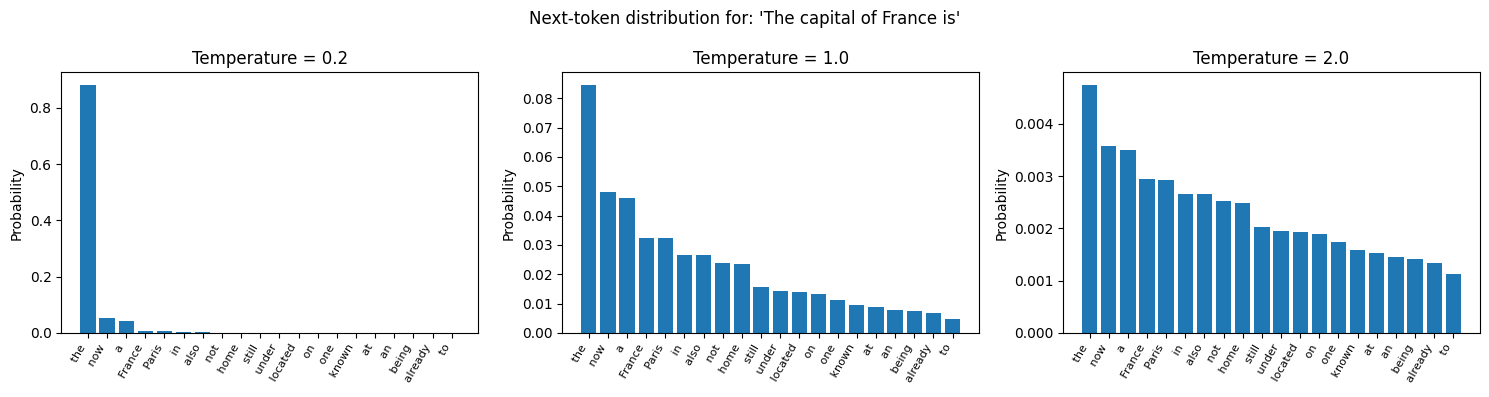


Notice: low temperature → probability concentrates on Paris.
High temperature → probability spreads across many tokens.

Actual top-1 token at T=1.0: ' the'


In [ ]:
import matplotlib.pyplot as plt

# Visualise how temperature reshapes the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
temps = [0.2, 1.0, 2.0]

for ax, T in zip(axes, temps):
    scaled_logits = last_logits / T
    scaled_probs  = F.softmax(scaled_logits, dim=-1)
    top_p, top_i  = torch.topk(scaled_probs, 20)
    labels = [gpt2_tokenizer.decode([i.item()]) for i in top_i]

    ax.bar(range(20), top_p.numpy())
    ax.set_xticks(range(20))
    ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=8)
    ax.set_title(f"Temperature = {T}")
    ax.set_ylabel("Probability")

plt.suptitle(f"Next-token distribution for: '{prompt}'", fontsize=12)
plt.tight_layout()
plt.show()

print("\nNotice: low temperature → probability concentrates on Paris.")
# ↑ Slightly misleading — top token is actually ' the', not ' Paris' directly.
# GPT-2 predicts prose continuations, not direct answers.
# An instruction-tuned model (like Phi-3) would output 'Paris' directly.
print("High temperature → probability spreads across many tokens.")

# Show what the actual top token is
top1 = gpt2_tokenizer.decode([torch.argmax(last_logits).item()])
print(f"\nActual top-1 token at T=1.0: {repr(top1)}")



## **5) Sentence Embeddings and Semantic Search with `sentence-transformers`**

So far we have looked at **token-level** embeddings (one vector per token).  
For many downstream tasks we need a **single vector per sentence** that captures its overall meaning.

### How it works

1. Pass the sentence through a transformer encoder.
2. **Pool** the token representations (mean-pooling, CLS token, etc.) into one vector.
3. That vector lives in a semantic space where **cosine similarity ≈ semantic similarity**.

```
"A dog is chasing a ball"  →  encoder  →  [0.12, -0.34, ... , 0.08]  (384-d vector)
"The puppy runs after the sphere" →  [0.13, -0.33, ... , 0.09]   ← very similar!
"The stock market fell today" →    [-0.45,  0.21, ... , 0.51]    ← very different
```


In [ ]:
!pip install -q sentence-transformers


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# all-MiniLM-L6-v2: 22M parameters, 384-d embeddings, very fast
smodel = SentenceTransformer("all-MiniLM-L6-v2")
print("Sentence transformer loaded ")
print(f"Embedding dimension: {smodel.get_sentence_embedding_dimension()}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence transformer loaded 
Embedding dimension: 384


/tmp/ipykernel_14098/2030772492.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {smodel.get_sentence_embedding_dimension()}")


In [ ]:
# ── Similarity between sentence pairs ────────────────────────────────────
sentence_pairs = [
    ("A dog is chasing a ball.",     "The puppy runs after the sphere."),
    ("I love machine learning.",     "Deep learning is my passion."),
    ("I love machine learning.",     "The stock market crashed today."),
    ("Paris is the capital of France.", "Rome is in Italy."),
    ("The weather is nice today.",   "It is sunny outside."),
]

print(f"{'Sentence A':45} | {'Sentence B':45} | Similarity")
print("-" * 100)

for a, b in sentence_pairs:
    emb_a = smodel.encode([a])
    emb_b = smodel.encode([b])
    sim   = cosine_similarity(emb_a, emb_b)[0][0]
    print(f"{a[:44]:45} | {b[:44]:45} | {sim:.3f}")


Sentence A                                    | Sentence B                                    | Similarity
----------------------------------------------------------------------------------------------------
A dog is chasing a ball.                      | The puppy runs after the sphere.              | 0.497
I love machine learning.                      | Deep learning is my passion.                  | 0.650
I love machine learning.                      | The stock market crashed today.               | 0.090
Paris is the capital of France.               | Rome is in Italy.                             | 0.281
The weather is nice today.                    | It is sunny outside.                          | 0.583


### Semantic Search Demo

Traditional keyword search misses synonyms. Semantic search uses embeddings to find documents that *mean* the same thing as the query, even if they use different words.


In [ ]:
# ── Build a tiny "knowledge base" ────────────────────────────────────────
documents = [
    "The transformer architecture uses self-attention to relate tokens in a sequence.",
    "Backpropagation is an algorithm used to train neural networks by computing gradients.",
    "The Eiffel Tower is located in Paris, France.",
    "GPT stands for Generative Pre-trained Transformer.",
    "Convolutional neural networks are widely used for image classification tasks.",
    "BERT is an encoder-only transformer pre-trained with masked language modelling.",
    "The Amazon river is the world's largest river by water discharge.",
    "Gradient descent updates model parameters in the direction that reduces the loss.",
    "Attention mechanisms allow the model to focus on relevant parts of the input.",
    "Recurrent neural networks process sequences step by step, maintaining a hidden state.",
]

# Encode all documents once
doc_embeddings = smodel.encode(documents)
print(f"Encoded {len(documents)} documents into shape {doc_embeddings.shape}")


Encoded 10 documents into shape (10, 384)


In [ ]:
def semantic_search(query: str, top_k: int = 3):
    """Return the top_k most semantically similar documents to query."""
    query_emb = smodel.encode([query])                          # (1, 384)
    sims      = cosine_similarity(query_emb, doc_embeddings)[0] # (N,)
    top_idx   = np.argsort(sims)[::-1][:top_k]                 # highest first

    print(f"Query: '{query}'")
    print("-" * 70)
    for rank, idx in enumerate(top_idx, start=1):
        print(f"  #{rank} (sim={sims[idx]:.3f}): {documents[idx]}")
    print()


semantic_search("How do transformers pay attention to input?")
semantic_search("How are neural nets trained?")
semantic_search("What river has the most water flow?")


Query: 'How do transformers pay attention to input?'
----------------------------------------------------------------------
  #1 (sim=0.591): The transformer architecture uses self-attention to relate tokens in a sequence.
  #2 (sim=0.529): Attention mechanisms allow the model to focus on relevant parts of the input.
  #3 (sim=0.355): BERT is an encoder-only transformer pre-trained with masked language modelling.

Query: 'How are neural nets trained?'
----------------------------------------------------------------------
  #1 (sim=0.607): Backpropagation is an algorithm used to train neural networks by computing gradients.
  #2 (sim=0.453): Attention mechanisms allow the model to focus on relevant parts of the input.
  #3 (sim=0.401): Recurrent neural networks process sequences step by step, maintaining a hidden state.

Query: 'What river has the most water flow?'
----------------------------------------------------------------------
  #1 (sim=0.556): The Amazon river is the world's la

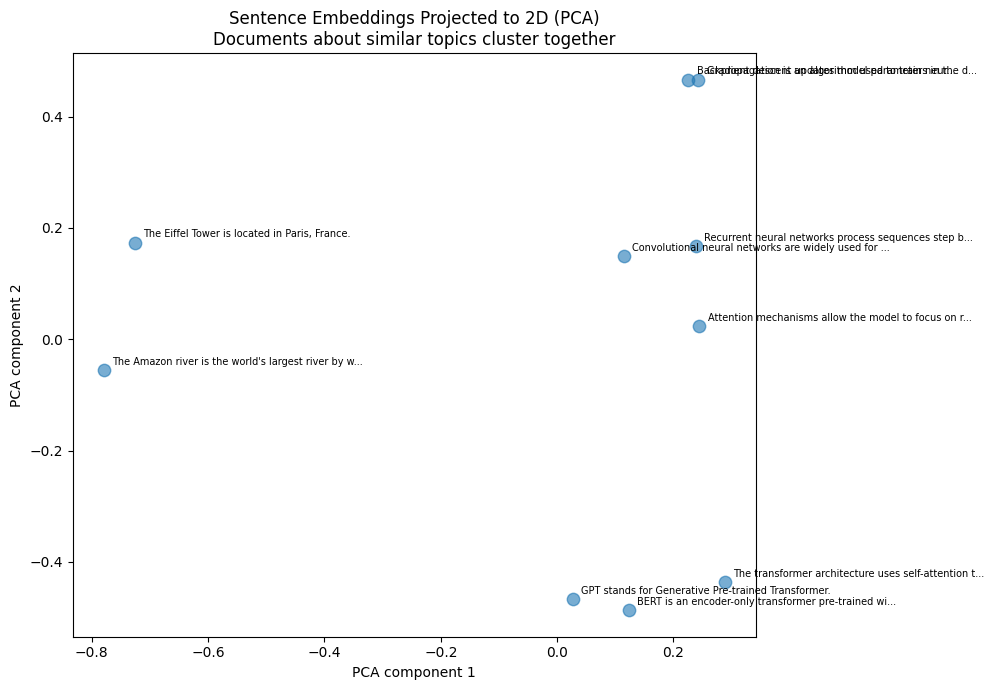

In [ ]:
# ── Visualise document embeddings in 2D with PCA ─────────────────────────
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
doc_2d = pca.fit_transform(doc_embeddings)  # (10, 2)

plt.figure(figsize=(10, 7))
plt.scatter(doc_2d[:, 0], doc_2d[:, 1], s=80, alpha=0.6)

for i, doc in enumerate(documents):
    # Truncate label for readability
    label = doc[:50] + "..." if len(doc) > 50 else doc
    plt.annotate(label, (doc_2d[i, 0], doc_2d[i, 1]),
                 textcoords="offset points", xytext=(6, 4), fontsize=7)

plt.title("Sentence Embeddings Projected to 2D (PCA)\n"
          "Documents about similar topics cluster together", fontsize=12)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.tight_layout()
plt.show()


# **C) LLM Embeddings**

Try to answer this: how would you represent the word "bank" as a number so a computer can reason about it?

The simplest answer — assign each word an integer ID — fails immediately. ID 4217 and ID 4218 are adjacent numbers, but "apple" and "zebra" have nothing to do with each other. Arithmetic on IDs is meaningless.

The next attempt — one-hot vectors — fixes the arithmetic problem but creates a new one: every word is equally distant from every other. "Cat" and "kitten" are as unrelated as "cat" and "democracy."

Embeddings are the solution that stuck. Instead of hand-crafting representations, we *learn* them from data — and let the training signal organise the space so that similar words cluster together, analogies become vector offsets, and context shifts meaning. By the end of this section, you will understand how that organisation emerges, how it evolved over twenty years of NLP research, and what it looks like inside a real production model (DeepSeek-R1-Distill-Qwen-1.5B).


## **What are Embeddings?**

- Processing text for NLP tasks requires a numeric representation of each word. Most embedding methods come down to turning a word or token into a vector. What makes these techniques different from each other, is how they approach this word → vector conversion.

- Embedding is not just for text, they can be applied to images, audio, or even graph data. In a general sense, embedding is the process of converting data [of any type] into vectors.

- Almost every embedding technique relies on a corpus of text data to extract the relationship of the word.

- In this section, we talk about "text" embeddings, the techniques for which have evolved over time.

- **Static vs. Dynamic (or contextualized) Embeddings:**
    - **Token Embeddings are Static.** These are the fixed vectors assigned to input tokens at the very beginning of an LLM.
    - The representations produced by the **deeper layers of the model** are **Contextualized**.  As training progresses, the intermediate hidden states evolve as they pass through each layer, capturing the full context of the input.

<img src="https://i-blog.csdnimg.cn/direct/e995063f63e149a4b5ff4e1f8f6d4146.png" width="800px">

### Static vs. Contextualised Embeddings

**Token Embeddings are Static.** These are fixed vectors assigned to input tokens at the very beginning of an LLM — a lookup table where every token ID maps to the same vector regardless of where it appears. Ask for the embedding of "bank" and you always get the same 768-dimensional vector, whether the sentence is about money or rivers.

**Deeper layer representations are Contextualised.** As a token's hidden state passes through successive Transformer layers, self-attention allows it to incorporate information from every other token in the sequence. The representation of "bank" at layer 12 is a completely different vector depending on its surrounding context — *this* is where the model resolves ambiguity.

A useful mental model:

```
Input tokens   →   [Static Embedding Layer]   →   same vector every time
                           ↓
              [Transformer Layer 1: self-attention + FFN]
                           ↓
              [Transformer Layer 2: self-attention + FFN]
                           ↓  ... (N layers)
              [Transformer Layer N]   →   contextualised representation
```

The static layer gives the model a starting point; the deeper layers do the interpretive work.

---


## **What Makes a Good Embedding?**



### 1. Quality of Semantic Representation
Embeddings must capture the semantic relationships between words. Words with similar meanings should be placed close together in the vector space, and unrelated words must be set apart. The vectors of "cat" and "dog" should be more similar than "dog" and "barrel."

This goes beyond simple synonymy — good embeddings also encode **relational structure**:
- *Analogy*: `king − man + woman ≈ queen` (gender offset is consistent)
- *Hierarchy*: `poodle` sits closer to `dog` than to `animal` in the space
- *Sentiment*: positive words cluster away from negative ones
### 2. Dimensionality Efficiency
How large should embedding vectors be — 50 dimensions? 300? 768? Striking the right balance is critical:

| Embedding size | Trade-off |
|----------------|-----------|
| Small (50–100d) | Memory-efficient, fast, but may miss subtle relationships |
| Medium (300d) | Sweet spot for classical methods like Word2Vec / GloVe |
| Large (768–4096d) | Captures rich structure; standard for Transformer models; prone to overfitting on small datasets |

For reference, GPT-2 uses 768 dimensions (small variant) up to 1,600 dimensions (XL variant). LLaMA-3-8B uses 4,096.

### 3. Handling Out-of-Vocabulary (OOV) Tokens
A word-level vocabulary will inevitably encounter words it has never seen. How the embedding method handles this matters:

- **Word-level methods** (Word2Vec, GloVe): assign `<UNK>` — all unknown words collapse to the same vector, losing all information.
- **Subword methods** (BPE, WordPiece): decompose the unknown word into known sub-units. "ChatGPT" might become `["Chat", "G", "PT"]` — each piece has a vector, and the model can still reason about the whole.
- **Byte-level BPE** (GPT-2): falls all the way back to raw bytes if needed — truly zero unknown tokens.
### 4. Polysemy — One Word, Many Meanings
The word "light" can mean a photon, a low-calorie food, or the act of igniting something. Static embeddings assign it a single vector — a blurred average of all meanings. Contextualised embeddings solve this: the hidden state of "light" diverges depending on context, giving the model distinct representations for each sense.

### 5. Computational Cost vs. Downstream Performance
Richer embeddings are more expensive to compute and store:

- **TF-IDF**: sparse, near-instant, no GPU needed
- **Word2Vec / GloVe**: dense, cheap to look up after training, no GPU at inference
- **Transformer embeddings**: require a full forward pass through potentially billions of parameters


## **TF-IDF (Term Frequency-Inverse Document Frequency):**

The idea of TF-IDF is to calculate the importance of a word in a document by considering two factors[1]:
1. **Term-Frequency (TF)**: How frequent a term appears in a document. A higher TF shows that a term is more important to the document.

2. **Inverse Document Frequency (IDF)**: How rare a term is across documents. This is based on the assumption that terms that appear in many of the documents are less important than terms that are unique to fewer documents.

$$
\text{tf}(t,d) = \begin{cases}
- 1 + \log_e(f_{t,d}) & \text{if } f_{t,d} > 0 \\
- 0 & \text{if } f_{t,d} = 0
\end{cases}
$$
where $f_{t,d}$ is the raw frequency of term $t$ in document $d$


$$
\text{idf}(t,\mathcal{D}) = \log\left(\frac{N + 1}{\text{df}(t) + 1}\right) + 1
$$
where:

- $t$ is a term in the vocabulary
- $\mathcal{D}$ is the corpus of documents
- $N$ is the total number of documents in $\mathcal{D}$
- $\text{df}(t)$ is the document frequency of term $t$


Now let's start use TF-IDF using the [TinyShakespeare](https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt) dataset.

In [ ]:
import os
import urllib.request

if not os.path.exists("tinyshakespeare.txt"):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    file_path = "tinyshakespeare.txt"


    urllib.request.urlretrieve(url, file_path) # Download the file from the internet and save it locally
    print(f"Downloaded {file_path} from {url}")
else:
    file_path = "tinyshakespeare.txt"
    print(f"{file_path} already exists.")

with open("tinyshakespeare.txt", "r") as file:
    corpus = file.read() # Load the entire text into a single string variable
print(f"Text corpus includes {len(corpus.split())} words.")


N = len(corpus) // 10


documents = [corpus[i:i+N] for i in range(0, len(corpus), N)] # Create a list of 10 'documents' by slicing the corpus into blocks of size N

documents = documents[:-1]
# Result: We now have a list (documents) containing 9 equal-sized text chunks

Downloaded tinyshakespeare.txt from https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Text corpus includes 202651 words.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer() # Initialize the TF-IDF tool which calculates word importance

# 1. 'fit' learns the vocabulary from your Shakespeare documents
# 2. 'transform' converts those documents into a matrix of importance scores
embeddings = vectorizer.fit_transform(documents)
words = vectorizer.get_feature_names_out() # Extract the actual words (features) that the vectorizer found in the text
print(f"Word count: {len(words)} e.g.: {words[:10]}")

print(f"Embedding shape: {embeddings.shape}")

Word count: 11446 e.g.: ['abandon' 'abase' 'abate' 'abated' 'abbey' 'abbot' 'abed' 'abel' 'abet'
 'abhor']
Embedding shape: (10, 11446)


let's now visualize the embeddings in 2d space.

- Your TF-IDF matrix has over ~11,000 "features" (one for every word in Shakespeare). Humans cannot visualize an 11,000-dimensional space. PCA finds the two most important "directions" of variation in the data and projects the words onto them. Words that appear in similar documents will end up closer together on this 2D map.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Initialize Principal Component Analysis to reduce data to 2 dimensions
pca = PCA(n_components=2)

# Transpose the matrix (T) so words are rows, then compress them into 2D coordinates
emb_2d = pca.fit_transform(embeddings.T)

In [ ]:

import plotly.graph_objects as go
import pandas as pd

# Organize the 2D coordinates (x, y) and their corresponding words into a table
df_plot = pd.DataFrame({
    'x': emb_2d[:, 0], # First principal component
    'y': emb_2d[:, 1], # Second principal component
    'word': words      # The actual text label
})

# Calculate the Euclidean distance from the center (0,0) to use for color-coding
df_plot['distance'] = np.sqrt(df_plot['x']**2 + df_plot['y']**2)

# Pick a maximum of 1500 words at random to prevent the plot from being too cluttered
sample_size = min(1500, len(df_plot))
df_sample = df_plot.sample(n=sample_size)

# Create an interactive scatter plot
fig = go.Figure(data=[
    go.Scatter(
        x=df_sample['x'],             # Use the first PCA coordinate for horizontal axis
        y=df_sample['y'],             # Use the second PCA coordinate for vertical axis
        mode='markers+text',          # Display both a dot and the word label
        text=df_sample['word'],       # Define which column holds the labels
        textposition='top center',    # Place labels above the dots
        textfont=dict(
            color='rgba(0,0,0,0.5)'  # Make the text semi-transparent for readability
        ),
        marker=dict(
            size=6,                  # Size of the dots
            opacity=0.7,             # Transparency of the dots
            color=df_sample['distance'], # Color dots based on distance from origin
            colorscale='plasma',     # Use the 'plasma' color palette (Purple to Yellow)
            showscale=False          # Do not show the color legend bar
        ),
        # Define what appears when you hover your mouse over a dot
        hovertemplate='x: %{x:.2f}<br>y: %{y:.2f}<br>word: %{text}<extra></extra>'
    )
])

# Fine-tune the visual appearance of the plot
fig.update_layout(
    coloraxis_showscale=False, # Disable the color scale sidebar
    width=800,                 # Set width of the chart in pixels
    height=600,                # Set height of the chart in pixels
    showlegend=False,          # Hide the legend as it's not needed for 1 category
    xaxis_title=None,          # Remove X-axis label for a cleaner look
    yaxis_title=None,          # Remove Y-axis label for a cleaner look
    margin=dict(l=30, r=30, t=30, b=30), # Tighten the margins
    paper_bgcolor='white',     # Set the background to white
)

# Render the interactive plot in the notebook
fig.show()

# Export the interactive chart as a standalone HTML file
fig.write_html(
    "tfidf-emb.html",
    include_plotlyjs='cdn',
    full_html=True
)

In [ ]:
# use plotly to visualize the embeddings
import plotly.express as px
import pandas as pd

# Create a structured table (DataFrame) to hold our compressed 2D coordinates and words
df_plot = pd.DataFrame({
    'x': emb_2d[:, 0], # Horizontal position from PCA
    'y': emb_2d[:, 1], # Vertical position from PCA
    'word': words      # The label for each point
})

# Create the scatter plot using the express API
fig = px.scatter(
    df_plot,
    x='x',           # Map the 'x' column to the horizontal axis
    y='y',           # Map the 'y' column to the vertical axis
    text='word',     # Tell Plotly to display the word itself on the plot
)

# Display the interactive chart in your current environment (e.g., Jupyter)
fig.show()

# Use Plotly's Input/Output module to export the result
import plotly.io as pio
pio.write_html(
    fig,
    file='tfidf-emb.html', # Name of the saved file
    auto_open=True,        # Automatically open the file in your browser after saving
    include_plotlyjs=True, # Include the JavaScript library so the file works offline
    full_html=True         # Generate a complete webpage file
)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
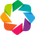

In [ ]:
import pandas as pd
import holoviews as hv
hv.extension('bokeh')

df = pd.DataFrame({
    'x': emb_2d[:, 0],
    'y': emb_2d[:, 1],
    'word': list(words)
})

# sample of words we are interested in
special_words = ['dog', 'cat', 'animal', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']
# show only 200 words that are not special, otherwhise the plot would be too dense
mask = df['word'].isin(special_words)
non_special_df = df[~mask].sample(n=200, random_state=42)
special_df = df[mask]
df = pd.concat([special_df, non_special_df])

# show special words in red
df['color'] = 'gray'
df.loc[df['word'].isin(special_words), 'color'] = 'red'

df['size'] = 5
df.loc[df['word'].isin(special_words), 'size'] = 15

# add label color column
df['label_color'] = 'gray'
df.loc[df['word'].isin(special_words), 'label_color'] = 'red'

points = hv.Points(df, kdims=['x', 'y'], vdims=['word', 'color', 'size', 'label_color'])

# add labels and customize
labels = hv.Labels(points, ['x', 'y'], ['word', 'label_color'])

# Create plot with separate options for Points and Labels
points_opts = hv.opts.Points(
    width=800, height=600,
    tools=['hover', 'box_zoom', 'wheel_zoom', 'pan', 'reset'],
    alpha=0.3,  # More transparent for regular words
    color='color',
    size='size'
)

labels_opts = hv.opts.Labels(
    text_font_size='8pt',
    text_color='label_color'
)

plot = (points.opts(points_opts) * labels.opts(labels_opts)).opts(
    xlabel='Component 1',
    ylabel='Component 2'
)

# Save the plot
hv.save(plot, 'tf-idf-embeddings.html')


In [ ]:
plot

:Overlay
   .Points.I :Points   [x,y]   (word,color,size,label_color)
   .Labels.I :Labels   [x,y]   (word,label_color)

Because TF-IDF is based on the occurance frequency of terms in the document, it doesn't hold any semantic meanings. Vectors that are similar to each other are irrelevant in meaning. And words that are semanticly close, like numbers from one to ten, have no relationship in the vector space. The inability of TF-IDF and similar approaches is what makes them unsuitable for many NLP tasks. However, the simplicity makes these methods useful in applications such as information retreival, keyword extraction, and basic text analysis. You can read about some of these methods in [2].

## **Word2Vec**

Originally proposed in [Efficient Estimation of Word Representations in Vector Space](https://arxiv.org/pdf/1301.3781), Word2Vec is a shallow neural network that learns to convert words into dense embedding vectors. It was a landmark moment in NLP — for the first time, word meaning could be encoded as geometry.

### The Core Idea: Learning by Predicting Context

Word2Vec does not learn embeddings directly. Instead it defines a **proxy task** — a prediction problem that forces the network to develop useful representations as a side effect. The intuition is simple: *a word's meaning is defined by the company it keeps.* If "coffee" and "tea" appear near the same words ("hot", "drink", "morning", "cup"), they should end up close in the embedding space.

Two proxy tasks were proposed, giving two variants:

| Variant | Input | Prediction target |
|---------|-------|-------------------|
| **CBOW** (Continuous Bag of Words) | Surrounding context words | The missing centre word |
| **Skip-gram** | A single centre word | The surrounding context words |

CBOW is faster to train and works better on frequent words. Skip-gram is slower but performs better on rare words and smaller datasets. Both produce equivalent embeddings — they just frame the task differently.


### CBOW: Architecture and Step-by-Step




The network has three components:

- **Input layer**: C context words, each represented as a one-hot vector of size V (vocabulary size). So the full input is C × V dimensions.
- **Hidden layer**: A single linear layer of size N (the embedding dimension). No activation function — the output is passed unchanged. Its weight matrix W of shape V × N is what we are actually after.
- **Output layer**: A weight matrix W′ of shape N × V maps the hidden state to V scores, one per vocabulary word. A softmax converts these to probabilities.
Here is how CBOW works step by step for the sentence *"This is \_ great book"* with context window = 2:

1. **Choose a target word** — the blank we want to predict (here: "a")
2. **Select context words** — the C = 4 words around it: "This", "is", "great", "book"
3. **One-hot encode each context word** — each becomes a 1 × V vector with a single 1 at its vocabulary index; all other entries are 0
4. **Pass each one-hot vector through W** — this is just a row lookup. The row corresponding to the word's index in W is its embedding. The hidden layer has a linear activation, so the output equals the input multiplied by W.
5. **Average the C hidden representations** — the four context embeddings are mean-pooled into a single N-dimensional vector h
6. **Project through W′ and apply softmax** — h is multiplied by W′ to produce V scores; softmax converts them to a probability distribution over the vocabulary
7. **Pick the highest-probability token** — the word with the highest score is the network's prediction




<img src="https://i-blog.csdnimg.cn/direct/16a7b55fc918487187c751b6412a3b81.png" width="700px">

*Figure: word2vec in a CBOW example*

### Where Do the Embeddings Come From?

Here is the key insight that makes Word2Vec work: **the weight matrix W (V × N) is the embedding table.**

When you feed a one-hot vector for word *i* into the network, the multiplication one-hot × W simply selects row *i* of W — no actual computation happens. This means each row of W is the N-dimensional embedding of one vocabulary word. After training, the output layer W′ is discarded. We only keep W.

```
one-hot([0, 0, 1, 0, ...])  ×  W(V × N)  =  row 2 of W  =  embedding of word 2
```

The training signal — predicting the correct missing word — forces the rows of W to organise themselves so that words appearing in similar contexts end up in similar positions in the N-dimensional space. The network never explicitly learns "cat and dog are similar." It discovers that indirectly, because both words appear near "pet", "feed", "vet", "play", and so on.



### Skip-gram: The Reverse Direction

Skip-gram flips the task: given a single centre word as input, predict each of its C context words individually. The architecture is symmetric — same W and W′ matrices — but each training example produces C separate prediction problems instead of one.

This makes Skip-gram slower but gives it more training signal per word, which is why it handles rare words better than CBOW.

---

### What Word2Vec Captures — and What It Cannot

**Strengths:**

- **Semantic relationships**: words with similar meanings cluster together. "Paris" and "Rome" are close; "Paris" and "hammer" are not.
- **Relational structure / analogy**: the famous result `king − man + woman ≈ queen` holds because the gender offset and the royalty offset are consistent directions in the vector space — they were learned implicitly from context patterns across the entire corpus.
- **Dimensionality**: a 300-d dense vector carries far more information than a 50,000-d sparse one-hot vector, and is much cheaper to compute with.
**Limitations:**

- **Static embeddings**: every word gets exactly one vector. "Bank" has the same embedding whether the sentence is about finance or rivers. The model averages over all senses seen during training.
- **No subword structure**: "running" and "runs" are different entries in the vocabulary — the model must see both during training or it cannot embed them. Rare or misspelled words are reduced to `<UNK>`.
- **Window-limited context**: only the local context window (typically 2–5 words) is used. Long-range dependencies in a sentence are invisible to Word2Vec.
These limitations are precisely what motivated the move to Transformer-based contextualised embeddings, covered next.

---

### Visualising the Embedding Space

Once trained, Word2Vec embeddings can be projected to 2D (via PCA or t-SNE) to see the structure the network learned:

<img src="https://i-blog.csdnimg.cn/img_convert/ba5a4d915310cc050957cdde00f9f4ca.png" width="700px">

*Figure: Word2Vec embeddings visualisation — note how countries, capitals, and verb tenses each form coherent clusters, and how the offset between a country and its capital is approximately consistent across pairs.*

Countries cluster near other countries. Capitals cluster near other capitals. The vector from "France" to "Paris" is nearly parallel to the vector from "Italy" to "Rome." This geometric regularity is not hand-coded — it emerges purely from predicting context words across a large corpus.

---

### Using a Pre-trained Word2Vec Model

Google trained Word2Vec on ~100 billion words from Google News, producing 3 million word vectors of 300 dimensions each. You can download it from [Google's official page](https://code.google.com/archive/p/word2vec/) and load it via `gensim`:

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 92.0 MB/s eta 0:00:00


In [ ]:
import os
KAGGLE_USERNAME = "rajdp2k"
KAGGLE_KEY = "KGAT_35ce79f203204bbf038fbc261c143527"
os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = KAGGLE_KEY

In [ ]:
!pip install -q kaggle
!kaggle datasets download -d leadbest/googlenewsvectorsnegative300
!unzip googlenewsvectorsnegative300.zip


Dataset URL: https://www.kaggle.com/datasets/leadbest/googlenewsvectorsnegative300
License(s): other
 99% 3.14G/3.17G [00:51<00:07, 4.97MB/s]
100% 3.17G/3.17G [00:51<00:00, 65.9MB/s]
Archive:  googlenewsvectorsnegative300.zip
  inflating: GoogleNews-vectors-negative300.bin  
  inflating: GoogleNews-vectors-negative300.bin.gz  


In [ ]:
import gensim

# Load a massive pre-trained model containing 3 million words
# This 'Google News' model was trained on roughly 100 billion words
model = gensim.models.KeyedVectors.load_word2vec_format(
    "GoogleNews-vectors-negative300.bin.gz",
    binary=True
)

In [ ]:
# Display the length of the vector (300 numbers for every word)
print(f"The embedding size: {model.vector_size}")

# Display the total number of unique words in the model (3,000,000)
print(f"The vocabulary size: {len(model)}")

The embedding size: 300
The vocabulary size: 3000000


In [ ]:
# italy - rome + london = england
model.most_similar(positive=['london', 'italy'], negative=['rome'])

[('england', 0.5743449330329895),
 ('europe', 0.537047266960144),
 ('liverpool', 0.5141493678092957),
 ('chelsea', 0.5138063430786133),
 ('barcelona', 0.5128480792045593),
 ('birmingham', 0.5125836730003357),
 ('spain', 0.4980141520500183),
 ('sweden', 0.49154016375541687),
 ('leeds', 0.4871763586997986),
 ('holland', 0.4858900308609009)]

In [ ]:
# the release of word2vec sparked conversations on social bias
model.most_similar(positive=['woman', 'doctor'], negative=['man'])

[('gynecologist', 0.7093892097473145),
 ('nurse', 0.6477287411689758),
 ('doctors', 0.6471460461616516),
 ('physician', 0.6438996195793152),
 ('pediatrician', 0.6249487996101379),
 ('nurse_practitioner', 0.6218312978744507),
 ('obstetrician', 0.6072014570236206),
 ('ob_gyn', 0.5986713171005249),
 ('midwife', 0.5927062630653381),
 ('dermatologist', 0.5739566683769226)]

To train word2vec efficiently, especially with large vocabularies, an optimization technique called negative sampling is used. Instead of computing the full softmax over the entire vocabulary (which is computationally expensive), negative sampling simplifies the task by updating only a small number of negative examples (i.e., randomly selected words not related to the context) along with the positive ones. This makes training faster and more scalable.

The semantic relationship is a fun topic to explore and word2vec is a simple setup for your experiments. You can explore the biases of society or the data, or explore how words have evolved over time by studying the embeddings of older manuscripts.

You can actually visualize and play with word2vec embeddings with [Tensorflow Embedding Projector](https://projector.tensorflow.org/).

## **BERT (Bidirectional encoder representations from transformers)**

BERT is the Sopranos of the NLP world — it's old, but you find references to it in whatever you look for. It's a good idea to do yourself a favour and learn about BERT once and for all, as it is the source of many ideas and techniques in modern LLMs. Here's a good [video](https://www.youtube.com/watch?v=90mGPxR2GgY) to get started.

---

### What is BERT and Why Did it Matter?

Before BERT (2018), the standard approach was to train a language model and use its static embeddings (like Word2Vec or GloVe) as features for downstream tasks. The embeddings were fixed — the same vector for "bank" regardless of context — and the task-specific model had to figure out the rest.

BERT flipped this entirely. Instead of frozen embeddings, BERT offered **deep contextualised representations**: every token's vector is shaped by all other tokens in the sentence via self-attention, across 12 (or 24) stacked Transformer encoder layers. You then fine-tune the *entire* pre-trained model on your specific task, not just a small head on top of frozen features.

The result was state-of-the-art on 11 NLP benchmarks at once. It showed that **pre-training on raw text + fine-tuning** was a more powerful paradigm than task-specific architectures trained from scratch.


### Architecture: Four Components

BERT is an **encoder-only** Transformer consisting of four main parts:

**1. Tokenizer**
Chops text into a sequence of integers using WordPiece subword tokenization. Similar to BPE, it handles unknown words by decomposing them into known sub-units. "unbelievable" might become `["un", "##believe", "##able"]` — the `##` prefix signals a continuation of the previous token.

**2. Embedding Layer**
Converts discrete token IDs into dense vectors. BERT actually sums *three* separate embeddings for each token:

```
Final embedding = Token embedding + Segment embedding + Positional embedding
```

- **Token embedding**: the vector for the token itself (from a V × 768 table)
- **Segment embedding**: encodes which sentence the token belongs to (Sentence A or Sentence B) — needed for the NSP pre-training task
- **Positional embedding**: encodes the position of the token in the sequence (learned, not sinusoidal like the original Transformer)

**3. Encoder Stack**
A stack of Transformer encoder blocks. BERT-base has 12 layers; BERT-large has 24. Each block contains:
- Multi-head self-attention (every token attends to every other token bidirectionally)
- A position-wise feed-forward network
- Layer normalisation and residual connections
The key word is **bidirectional** — unlike GPT which can only attend to past tokens (left-to-right), BERT attends in both directions simultaneously. This gives it a richer understanding of context: the representation of "bank" at layer 12 depends on both the words before *and* after it.

**4. Task Head**
After the encoder produces contextualised representations, a small task-specific head handles the final prediction:
- **Classification** (e.g. sentiment): use the [CLS] token's final representation → linear layer → softmax
- **Token labelling** (e.g. NER): use each token's final representation → linear layer → per-token labels
- **Question answering**: predict start and end positions of the answer span in the passage


### Pre-training: How BERT Learns Language

BERT is pre-trained on BookCorpus (800M words) + English Wikipedia (2.5B words) using two tasks simultaneously:

#### Task 1 — Masked Language Modelling (MLM)

15% of input tokens are randomly selected. Of those:
- 80% are replaced with `[MASK]`
- 10% are replaced with a random word
- 10% are left unchanged
The model must predict the original token at each masked position. This forces BERT to build rich contextual representations — it cannot just copy the input token, it must *reason* about what fits given the surrounding context.

```
Input:  "I [MASK] this book before the exam"
Target: "I  read  this book before the exam"
```

The random-replacement trick (10% + 10%) prevents the model from learning to blindly trust `[MASK]` tokens and ignoring unchanged ones — it must treat every token as potentially informative.


#### Task 2 — Next Sentence Prediction (NSP)

Given two sentences A and B separated by `[SEP]`, the model predicts whether B actually follows A in the original text (50% of the time it does; 50% of the time B is a random sentence).

```
[CLS] The dog chased the cat. [SEP] It ran under the table. [SEP]  →  IsNext
[CLS] The dog chased the cat. [SEP] Photosynthesis uses sunlight. [SEP]  →  NotNext
```

This task teaches BERT about inter-sentence coherence — useful for tasks like question answering and natural language inference where understanding the relationship between two texts matters.

> **Note:** Later research (RoBERTa, 2019) found that NSP actually hurts more than it helps, and dropping it improved performance. But the idea was influential at the time.


<img src="https://i-blog.csdnimg.cn/img_convert/1d9275f9be087faa2066ba38df6955dd.png" width="800px">

*Figure: Overview of BERT architecture*

### The Special Tokens: [CLS] and [SEP]

**[CLS] — Classification token**
Always prepended as the very first token of the input. As the sequence passes through all 12 encoder layers, self-attention allows [CLS] to accumulate information from every other token in the sequence. By the final layer, its representation is a single vector that summarises the entire input — this is what gets passed to the classification head for sentence-level tasks.

Think of [CLS] as a designated aggregator: it has no lexical meaning of its own, so the model learns to use it purely as a global "what is this sequence about?" slot.

**[SEP] — Separator token**
Marks the boundary between two input sequences (Sentence A and Sentence B). During NSP pre-training, the model learns that [SEP] signals a sentence boundary. It is also used at the end of a single-sentence input to signal end-of-sequence.

A full BERT input for a two-sentence task looks like:

```
[CLS]  tok_1  tok_2  ...  tok_n  [SEP]  tok_1  tok_2  ...  tok_m  [SEP]
  ↑                                ↑                                  ↑
aggregator                    boundary                           end marker
```

---

### Pre-training vs. Fine-tuning

This two-phase paradigm is one of BERT's most influential contributions:

| Phase | Data | What is learned |
|-------|------|-----------------|
| **Pre-training** | Massive unlabelled text (Wikipedia + Books) | General language understanding — grammar, facts, coreference, semantics |
| **Fine-tuning** | Small labelled dataset for your task | Task-specific decision boundaries on top of general representations |

Because the pre-trained weights already encode rich language knowledge, fine-tuning needs surprisingly little labelled data and very few training steps (typically 3–5 epochs). This is why BERT democratised NLP — you no longer needed millions of labelled examples to build a strong classifier.


**So why is BERT important?**

BERT is among the first instances of Transformer-based **contextualized, dynamic embeddings**. When given a sentence as input, the layers of the BERT model leverage self-attention and feed-forward mechanisms to update incorporate context from all other tokens in the sentence. The final output of each Transformer layer is a contextualized representation of the word which depending on the context, would be differnet.

### **Contextualized Word Embeddings From the BERT Language Model**

In [ ]:
from transformers import AutoModel, AutoTokenizer

# Load the tokenizer that matches the model's vocabulary and rules
# DeBERTa uses a different sub-word logic than standard BERT
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")

# Load the 'Body' of the model (the Transformer architecture)
# This model converts token IDs into deep, contextualized vectors
model = AutoModel.from_pretrained("microsoft/deberta-v3-xsmall")

# Convert the raw string into a dictionary of PyTorch tensors (input_ids and attention_mask)
# 'return_tensors=pt' prepares the data specifically for PyTorch
tokens = tokenizer('Hello world', return_tensors='pt')

# Pass the tokens through the model (the ** unpacks the dictionary)
# We take the first element [0], which is the 'last_hidden_state'
output = model(**tokens)[0]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/241M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

In [ ]:
output.shape # The tensor shape represents [batch_size, sequence_length, embedding_dimension]

torch.Size([1, 4, 384])

In [ ]:
for token in tokens['input_ids'][0]:
    print(tokenizer.decode(token))

[CLS]
Hello
 world
[SEP]


In [ ]:
output

tensor([[[-3.4816,  0.0861, -0.1819,  ..., -0.0612, -0.3911,  0.3017],
         [ 0.1898,  0.3208, -0.2315,  ...,  0.3714,  0.2478,  0.8048],
         [ 0.2071,  0.5036, -0.0485,  ...,  1.2175, -0.2292,  0.8582],
         [-3.4278,  0.0645, -0.1427,  ...,  0.0658, -0.4367,  0.3834]]],
       grad_fn=<NativeLayerNormBackward0>)

## **Embeddings in Modern LLMs**


Modern LLMs, such as the GPT family or the recent Deepseek model, use embeddings as a foundational component. In the context of Large Language Models, "embeddings" is a broad term. For the purpose of this lecture, we focus on "embeddings" as the module that transforms tokens into vector representations.

### **Where does the embedding fit into LLMs?**
In transformer-based models, the term "embedding" can refer to both static embeddings and dynamic contextual representations:

1. **Static Embeddings** are generated in the first layer and combine token embeddings (vectors representing tokens) with positional embeddings (vectors encoding token's position in the sequence).

2. **Dynamic Contextual Representations**. As input tokens pass through the self-attention and feed-forward layers, their embeddings are updated to become contextual. These dynamic representations capture the meaning of tokens based on their surrounding context.

For example, the word "bank" appears both as "river bank" and "bank robbery", and while the **token embedding** of the word bank is the same in both cases, the transformations it goes through in the layers of the network account for the context of which the word "bank" appears in.

<img src="https://i-blog.csdnimg.cn/img_convert/3da81e2c12db7304df6184a169485298.png" width="500" style="display: block; margin: 0 auto;">

*Figure: Overview of how embeddings fit into the LLM architecture*


#### **LLM Embeddings are Trained**

LLM embeddings are optimized during the training process. Borrowing from Sebastian Raschka's [**Build a Large Language Model (From Scratch)**](https://itbooks.ir/assets/files/books/artificial-intelligence/build-a-large-language-model-from-scratch.pdf), " While we can use pretrained models such as Word2Vec to generate embeddings for machine learning models, LLMs commonly produce their own embeddings that are part of the input layer and are updated during training. The advantage of optimizing the embeddings as part of the LLM training instead of using Word2Vec is that the embeddings are optimized to the specific task and data at hand."

#### **torch.nn.Embedding**

The embedding layer in LLMs works as a look-up table. Given a list of indices (token ids) it returns their embeddings.

# <img src="https://i-blog.csdnimg.cn/img_convert/37406b608bed8fe97bf276a1d8c3b2e8.png" alt="embeddings_as_lookup.png" width="700" style="display: block; margin: 0 auto;"/>

*Visualization of how the embedding layer works as a lookup table. [Image source](https://itbooks.ir/assets/files/books/artificial-intelligence/build-a-large-language-model-from-scratch.pdf)*

The practical implementation of an embedding layer in PyTorch is done with `torch.nn.Embedding` which acts as a simple look-up table. There is nothing more special about this layer than a simple Linear layer, rather than it allows us to get output with indices as input rather than one-hot encodings. The Embedding layer is simply a Linear layer that works with indices.

# <img src="https://i-blog.csdnimg.cn/img_convert/7a9331e3dc0e6d61752061201708d3c4.png" alt="embedding_as_linear.png" width="700" style="display: block; margin: 0 auto;"/>

*Figure: Visualization of the embedding lookup process. [Image source](https://itbooks.ir/assets/files/books/artificial-intelligence/build-a-large-language-model-from-scratch.pdf)*

Now let's work with the embedding of a model and see some visuals!


## **Embeddings in Action: DeepSeek-R1-Distill-Qwen-1.5B**

Let's disect the embeddings of the distilled version of DeepSeek-R1 in the Qwen model. Some parts of the following code is inspired by [chrishayuk](https://github.com/chrishayuk/embeddings/tree/main). We begin by loading the deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B model from [Hugging Face](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B) and saving the embeddings.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

In [ ]:
tokenizer_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
model_name = tokenizer_name

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
tokenizer.add_special_tokens({'pad_token': '[PAD]'})

# Load the pre-trained model
model = AutoModel.from_pretrained(model_name)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

In [ ]:
# Extract the embeddings layer
embeddings = model.get_input_embeddings()

# Print out the embeddings
print(f"Extracted Embeddings Layer for {model_name}: {embeddings}")

# Save the embeddings layer
torch.save(embeddings.state_dict(), "embeddings_qwen.pth")

Extracted Embeddings Layer for deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B: Embedding(151936, 1536)


KeyboardInterrupt: 

Now let's load the embedding layer and work with it. The goal of separating the embedding from the other parts of the model, saving, and loading it is to get the embeddings of an input much faster and efficiently rather than doing a complete forward pass of the model.

In [ ]:
import torch.nn as nn

class EmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(EmbeddingModel, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

    def forward(self, input_ids):
        return self.embedding(input_ids)


vocab_size = 151936
dimensions = 1536
embeddings_filename = r"embeddings_qwen.pth"
tokenizer_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

# Initialize the custom embedding model
model = EmbeddingModel(vocab_size, dimensions)

# Load the saved embeddings from the file
saved_embeddings = torch.load(embeddings_filename)

# Ensure the 'weight' key exists in the saved embeddings dictionary
if 'weight' not in saved_embeddings:
    raise KeyError("The saved embeddings file does not contain 'weight' key.")

embeddings_tensor = saved_embeddings['weight']

# Check if the dimensions match
if embeddings_tensor.size() != (vocab_size, dimensions):
    raise ValueError(f"The dimensions of the loaded embeddings do not match the model's expected dimensions ({vocab_size}, {dimensions}).")

# Assign the extracted embeddings tensor to the model's embedding layer
model.embedding.weight.data = embeddings_tensor

# put the model in eval mode
model.eval()

Now let's see how a sentence is tokenized and then converted to embeddings.

In [ ]:
from prettytable import PrettyTable

def prompt_to_embeddings(prompt:str):
    # tokenize the input text
    tokens = tokenizer(prompt, return_tensors="pt")
    input_ids = tokens['input_ids']

    # make a forward pass
    outputs = model(input_ids)

    # directly use the embeddings layer to get embeddings for the input_ids
    embeddings = outputs

    # print each token
    token_id_list = tokenizer.encode(prompt, add_special_tokens=True)
    token_str = [tokenizer.decode(t_id, skip_special_tokens=True) for t_id in token_id_list]

    return token_id_list, embeddings, token_str


def print_tokens_and_embeddings(prompt:str):
    table = PrettyTable()

    token_id_list, embeddings, token_str = prompt_to_embeddings(prompt)

    headers = ["token_id", "token", "Embedding Vector"]
    token_emb_table = []
    for i, (t_id, t_str) in enumerate(zip(token_id_list, token_str)):
        embedding_values = embeddings[0][i].tolist()
        embedding_str = f"{embedding_values[0]:.6f}, {embedding_values[1]:.6f}, {embedding_values[2]:.6f} ... {embedding_values[-1]:.6f}"
        t_str = t_str.replace(" ",  "#")
        token_emb_table.append([t_id, t_str, embedding_str])

    table.title = "Token Embeddings"
    table.field_names = headers
    table.add_rows(token_emb_table)
    print(table)


In [ ]:
print_tokens_and_embeddings("HTML coders are not considered programmers")

+------------------------------------------------------------------------+
|                            Token Embeddings                            |
+----------+--------------+----------------------------------------------+
| token_id |    token     |               Embedding Vector               |
+----------+--------------+----------------------------------------------+
|  151646  |              | -0.027466, 0.002899, -0.005188 ... 0.021606  |
|   5835   |     HTML     | -0.018555, 0.000912, 0.010986 ... -0.015991  |
|  20329   |     #cod     | -0.026978, -0.012939, 0.021362 ... 0.042725  |
|   388    |     ers      | -0.012085, 0.001244, -0.069336 ... -0.001213 |
|   525    |     #are     | -0.001785, -0.008789, 0.006195 ... -0.016235 |
|   537    |     #not     |  0.016357, -0.039062, 0.045898 ... 0.001686  |
|   6509   | #considered  | -0.000721, -0.021118, 0.027710 ... -0.051270 |
|  54846   | #programmers | -0.047852, 0.057861, -0.069336 ... 0.005280  |
+----------+-------------

As you can see, the prompt is chopped into tokens. Each tokenizer has a different approach of breaking strings down into meaningful pieces and sometimes it can be surprising too! (coders = cod + ers)
Also, I have replaced the whitespace " " with # in tokens for easier understanding.

### **Visualize the embeddings**
Now let's run a visualization experiment. For a given prompt, we will find `n` closest embeddings to each token and visualize them in a 2d space.

In [ ]:
def find_similar_embeddings(target_embedding, n=10):
    """
    Find the n most similar embeddings to the target embedding using cosine similarity

    Args:
        target_embedding: The embedding vector to compare against
        n: Number of similar embeddings to return (default 3)

    Returns:
        List of tuples containing (word, similarity_score) sorted by similarity
    """
    # Convert target to tensor if not already
    if not isinstance(target_embedding, torch.Tensor):
        target_embedding = torch.tensor(target_embedding)

    # Get all embeddings from the model
    all_embeddings = model.embedding.weight

    # Compute cosine similarity between target and all embeddings
    similarities = torch.nn.functional.cosine_similarity(
        target_embedding.unsqueeze(0),
        all_embeddings
    )

    # Get top n similar embeddings
    top_n_similarities, top_n_indices = torch.topk(similarities, n)

    # Convert to word-similarity pairs
    results = []
    for idx, score in zip(top_n_indices, top_n_similarities):
        word = tokenizer.decode(idx)
        results.append((word, score.item()))

    return results


In [ ]:
# token_id_list, prompt_embeddings, prompt_token_str = prompt_to_embeddings("""bridge sunset melody shadow river mountain blanket forest silence breeze thunder golden mirror whisper lantern crystal horizon meadow village ocean journey echo twilight compass harvest spark canyon autumn shelter raindrop sunrise valley maple summit canyon flicker gentle sapphire feather rustic drift orchard skyline ember velvet tranquil misty cobblestone harbor ripple radiant willow solstice""")
# token_id_list, prompt_embeddings, prompt_token_str = prompt_to_embeddings("""AI agents will be the most hot topic of artificial intelligence in 2025.""")
token_id_list, prompt_embeddings, prompt_token_str = prompt_to_embeddings("""list""")
# token_id_list, prompt_embeddings, prompt_token_str = prompt_to_embeddings("""USA and China are the most prominent countries in AI.""")

tokens_and_neighbors = {}
for i in range(1, len(prompt_embeddings[0])):
    token_results = find_similar_embeddings(prompt_embeddings[0][i], n=20)
    similar_embs = []
    for word, score in token_results:
        if word.strip().lower() != prompt_token_str[i].strip().lower():
            similar_embs.append(word)
    tokens_and_neighbors[prompt_token_str[i]] = similar_embs

In [ ]:
all_token_embeddings = {}

# Process each token and its neighbors
for token, neighbors in tokens_and_neighbors.items():
    # Get embedding for the original token
    token_id, token_emb, _ = prompt_to_embeddings(token)
    all_token_embeddings[token] = token_emb[0][1]

    # Get embeddings for each neighbor token
    for neighbor in neighbors:
        # Replace # with space
        neighbor = neighbor.replace("#", " ")
        # Get embedding
        neighbor_id, neighbor_emb, _ = prompt_to_embeddings(neighbor)
        all_token_embeddings[neighbor] = neighbor_emb[0][1]

In [ ]:
import networkx as nx
import plotly.graph_objects as go
import random

In [ ]:
# Create the graph
G = nx.Graph()

# Add edges from tokens to their neighbors
for token, neighbors in tokens_and_neighbors.items():
    for neighbor in neighbors:
        G.add_edge(token, neighbor)

# Generate positions using spring layout with optimized parameters for atlas-like spread
k = 1
iterations = 250
pos = nx.spring_layout(G, k=k, iterations=iterations)  # Increased k for more spread
# works on colab
# pos = nx.forceatlas2_layout(G, max_iter=36)

# Define visualization dimensions
viz_width = 600  # Increased for better spread
viz_height = 500 # Increased for better spread

# Extract edge coordinates and scale them
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    # Scale coordinates to fill the width/height
    x0, x1 = x0 * viz_width, x1 * viz_width  # Scale x coordinates
    y0, y1 = y0 * viz_height, y1 * viz_height # Scale y coordinates
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

# Node coordinates and data - scale the positions
node_x = [pos[node][0] * viz_width for node in G.nodes()]
node_y = [pos[node][1] * viz_height for node in G.nodes()]
node_degrees = dict(G.degree())
# Assign colors using viridis colorscale
colors = []
components = list(nx.connected_components(G))

# Create a mapping of nodes to their colors
node_to_color = {}
node_opacities = []  # List to store opacity values
node_labels = []     # List to store node labels
hover_labels = []    # List to store hover labels
text_opacities = []  # List to store text opacities

# Assign component index to each node for colorscale mapping
node_component_indices = []
for node in G.nodes():
    # Find which component the node belongs to
    for i, component in enumerate(components):
        if node in component:
            node_component_indices.append(i)
            break

    # Set opacity and label based on whether it's a main token or neighbor
    if node in tokens_and_neighbors:  # Main token
        node_opacities.append(0.9)
        text_opacities.append(1.0)
        node_labels.append(node)
        hover_labels.append(node)
    else:  # Neighbor token
        node_opacities.append(0.6)
        text_opacities.append(0.0)  # Lower opacity for neighbor labels
        node_labels.append(node)  # Show label with lower opacity
        hover_labels.append(node)

node_sizes = [(degree + 5) * 1 for degree in node_degrees.values()]  # Increased node sizes

# Node trace with viridis colorscale
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=node_labels,  # Show all labels
    textposition="top center",
    textfont=dict(
        color=[f'rgba(0,0,0,{opacity})' for opacity in text_opacities]  # Set text opacity
    ),
    marker=dict(
        size=node_sizes,
        color=node_component_indices,
        colorscale='plasma',
        opacity=node_opacities,  # Use the conditional opacities
        line_width=0.5
    ),
    customdata=[[hover_labels[i], ' | '.join(G.neighbors(node))] for i, node in enumerate(G.nodes())],
    hovertemplate="<b>%{customdata[0]}</b><br>Similar tokens: %{customdata[1]}<extra></extra>",
    hoverlabel=dict(namelength=0)
)

# Edge trace with black edges
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='grey'),  # Set edge color to grey
    hoverinfo='none',
    mode='lines'
)

# Set up Plotly figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    width=600,
                    height=500,
                    paper_bgcolor='white',
                    plot_bgcolor='white',
                    showlegend=False,
                    margin=dict(l=0, r=0, t=0, b=0),
                    xaxis=dict(
                        showgrid=False,
                        zeroline=False,
                        showticklabels=False,
                    ),
                    yaxis=dict(
                        showgrid=False,
                        zeroline=False,
                        showticklabels=False,
                        scaleanchor="x",
                        scaleratio=1
                    )
                ))
fig.show()

fig.write_html(r"token-visualization-list.html",
               include_plotlyjs=False,
               full_html=False,
               config={
                   'displayModeBar': False,
                   'responsive': True,
                   'scrollZoom': False,
               })


# **Credits and Additional Resources**

*   Read [Build a Large Language Model From Scratch](https://itbooks.ir/assets/files/books/artificial-intelligence/build-a-large-language-model-from-scratch.pdf) book by [Sebastian Raschka](https://sebastianraschka.com">)
*   Follow the tutorial [Let's build the GPT Tokenizer - Andrej Karpathy](https://www.youtube.com/watch?v=zduSFxRajkE)
*   Read Chapter 2 of the [Hands-On Large Language Models](https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961) book by [Jay Alammar](https://www.linkedin.com/in/jalammar) and [Maarten Grootendorst](https://www.linkedin.com/in/mgrootendorst/).
*  [Different Types of Tokenizers](https://huggingface.co/learn/llm-course/en/chapter2/4)
*  [LLM Embeddings Explained: A Visual and Intuitive Guide](https://huggingface.co/spaces/hesamation/primer-llm-embedding)
*   Codes have been leveraged from:
    - [https://github.com/rasbt/LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)
    - [Let's build the GPT Tokenizer Colab Notebook](https://colab.research.google.com/drive/1y0KnCFZvGVf_odSfcNAws6kcDD7HsI0L?usp=sharing)
    - [Tokens and Token Embeddings](https://colab.research.google.com/github/HandsOnLLM/Hands-On-Large-Language-Models/blob/main/chapter02/Chapter%202%20-%20Tokens%20and%20Token%20Embeddings.ipynb)
    - [https://github.com/hesamsheikh/llm-mechanics/tree/main](https://github.com/hesamsheikh/llm-mechanics/tree/main)
*  **Additional Resources:**
    - [Fine-Tuning Your First Large Language Model (LLM) with PyTorch and Hugging Face](https://huggingface.co/blog/dvgodoy/fine-tuning-llm-hugging-face)
    - [Fine-tune and deploy an LLM on Google Colab Notebook with QLoRA and VertexAI](https://medium.com/@hugo_fernandez/fine-tune-and-deploy-an-llm-on-google-colab-notebook-with-qlora-and-vertexai-58a838a63845)
    - [Getting Started With Embeddings](https://huggingface.co/blog/getting-started-with-embeddings)